In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from tqdm import tqdm


### Loading in the Data


In [4]:
# Notebook cell 2: Load and Prepare Data
features = pd.read_csv("data/All_features_corrected_final_patient.csv")
labels = pd.read_csv("data/All_model.csv", header=None, names=["TumourModel"], skiprows=1)

df = pd.concat([features, labels], axis=1)
df["TumourModel"] = LabelEncoder().fit_transform(df["TumourModel"])  # 0=Basal, 1=Luminal

print("Data shape:", df.shape)
df.head(10)


Data shape: (2268, 95)


,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM SmallAreaLowGrayLevelEmphasis,GLSZM ZoneEntropy,GLSZM ZonePercentage,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,TumourModel
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,2.315100e+08,-1.937093e-10,-0.082498,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,0
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,4.821426e+08,-2.053864e-10,-0.082433,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,0
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,2.067381e+08,-2.151032e-10,-0.082486,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,0
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,2.133581e+08,-1.793762e-10,-0.082435,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,0
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,2.561433e+08,-1.935037e-10,-0.082480,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,0
5,10,62.204370,203.481139,1.903292e+06,-223972.715422,66.434042,22.497314,937.665771,50.385605,128.072725,...,2.826933e+08,-1.948756e-10,-0.082498,0.006055,132.403139,1.187810e+06,4.227548,-0.008536,-1.343135e+15,0
6,10,58.954342,193.788940,1.900940e+06,-229578.241909,64.411716,21.275051,860.438110,47.626174,122.059293,...,6.181529e+08,-2.094112e-10,-0.082443,0.004959,129.100591,1.426031e+06,3.838805,-0.008580,-1.341563e+15,0
7,10,60.520738,193.165366,1.900639e+06,-231543.913744,63.493423,20.359573,822.506897,46.665821,122.097256,...,9.826593e+08,-1.687853e-10,-0.082403,0.004423,128.631497,1.487336e+06,3.813342,-0.008584,-1.341206e+15,0
8,10,61.587937,195.608017,1.901263e+06,-232765.016674,64.310833,21.120937,851.327881,47.337724,123.831887,...,1.088356e+09,-1.622239e-10,-0.082421,0.004684,128.215734,1.505439e+06,3.736175,-0.008597,-1.340993e+15,0
9,104,105.531123,252.956763,1.893494e+06,-156943.982163,73.162018,3.641592,526.084534,45.778278,178.953387,...,4.586890e+08,-1.071634e-10,-0.081783,0.000804,141.363718,4.453179e+05,7.581497,-0.007443,-1.401968e+15,0


<Axes: xlabel='TumourModel'>

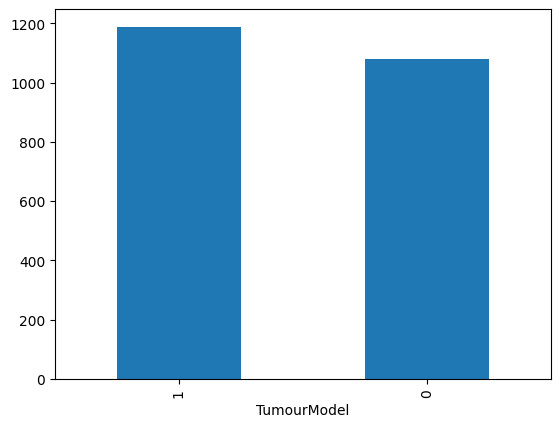

In [5]:
df["TumourModel"].value_counts().plot(kind="bar")

### Sensitivity Analysis (ANOVA)

In [6]:
# Notebook cell 3: η² calculation using F-statistics
X = df.drop(columns=["TumourModel", "PatientName"])
y = df["TumourModel"]

F_vals, p_vals = f_classif(X, y)
eta_squared = F_vals / (F_vals + df.shape[0] - 2)

eta_df = pd.DataFrame({
    "Feature": X.columns,
    "eta_squared": eta_squared,
    "p_value": p_vals
}).sort_values("eta_squared", ascending=False)

eta_df.head(10)


,Feature,eta_squared,p_value
14,FO Skewness,0.221161,3.641321e-125
0,FO 10Percentile,0.157595,1.736133e-86
8,FO Mean,0.153136,6.973989e-84
13,FO RootMeanSquared,0.130800,4.867688e-71
9,FO Median,0.125650,4.009557e-68
1,FO 90Percentile,0.124867,1.108618e-67
5,FO Kurtosis,0.121728,6.486254e-66
15,FO TotalEnergy,0.106596,1.763036e-57
2,FO Energy,0.106594,1.766553e-57
11,FO Range,0.096732,4.677917e-52


/var/folders/th/p1bpkycd1lx_c6j9tvg1m21c0000gn/T/ipykernel_4198/1110830980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="eta_squared", y="Feature", data=eta_df.head(20), palette="viridis")


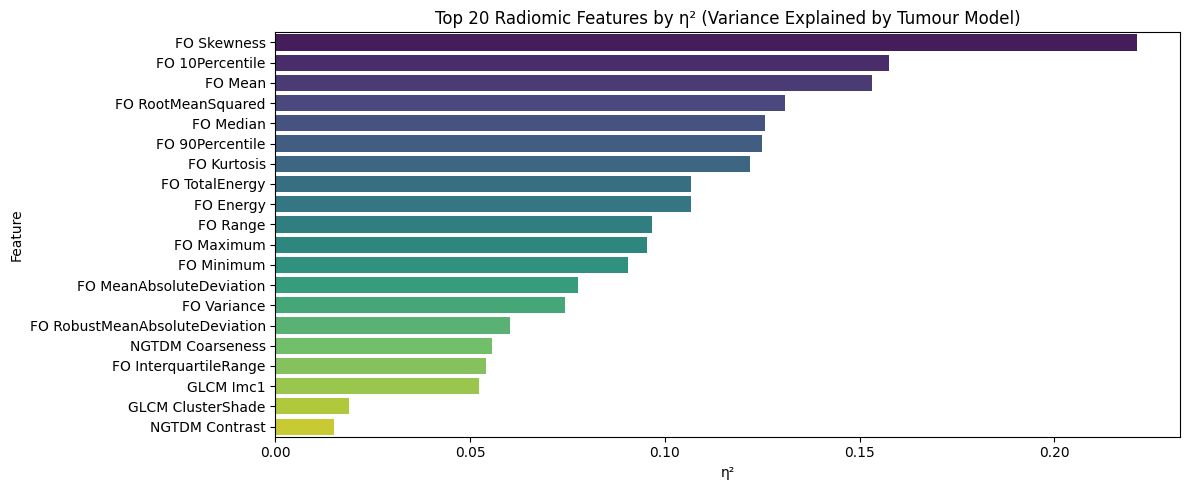

In [7]:
# Notebook cell 4: Plot η² values
plt.figure(figsize=(12, 5))
sns.barplot(x="eta_squared", y="Feature", data=eta_df.head(20), palette="viridis")
plt.title("Top 20 Radiomic Features by η² (Variance Explained by Tumour Model)")
plt.xlabel("η²")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## ANOVA - Corrected Features Used

In [ ]:
import pandas as pd
import os

# Load radiomic features (no metadata)
df_features = pd.read_csv("data/All_features_corrected_final_patient.csv")

# Load and concatenate all 12 metadata files
folder = "data/ModelsUncorrected"  # update to your path
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]

metadata_list = []
for f in sorted(csv_files):  # ensure consistent order!
    df = pd.read_csv(os.path.join(folder, f), usecols=["PatientName", "Model", "Wavelength", "GLbins"])
    df["Reconstruction"] = "MB" if "_MB" in f else "BP"
    metadata_list.append(df)

df_metadata = pd.concat(metadata_list, ignore_index=True)

# Final check
assert len(df_features) == len(df_metadata), "Row count mismatch!"

# Concatenate by row order
df_combined = pd.concat([df_features, df_metadata.drop(columns="PatientName")], axis=1)

# Convert to categorical for ANOVA
for col in ["Model", "Wavelength", "GLbins", "Reconstruction"]:
    df_combined[col] = df_combined[col].astype("category")

print("Combined shape:", df_combined.shape)
df_combined


Combined shape: (2268, 98)


,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,GLbins,Model,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,128,basal,700,BP
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,128,basal,730,BP
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,128,basal,750,BP
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,128,basal,760,BP
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,128,basal,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,98,992.082990,4457.898047,9.779358e+06,314845.586861,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,...,0.000031,96.333320,9.712949e+05,82287.526364,-0.001564,1.369483e+16,8,basal,770,MB
2264,98,851.154541,4067.293140,8.219187e+06,347907.061977,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,...,0.000031,96.332213,1.128664e+06,105620.991383,0.000838,1.634342e+16,8,basal,800,MB
2265,98,838.989789,4029.269922,8.086392e+06,353231.076936,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,...,0.000031,96.335268,1.169228e+06,104233.632403,0.001966,1.582569e+16,8,basal,820,MB
2266,98,878.749854,4083.819263,8.325601e+06,363272.297324,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,...,0.000031,96.333182,1.179483e+06,110186.114695,0.003280,1.493451e+16,8,basal,840,MB


In [201]:
# Step 2: Identify unique Luminal patients
luminal_patients = df_combined[df_combined["Model"] == "luminal"]["PatientName"].unique()

# Step 3: Drop one randomly (or pick first for reproducibility)
drop_patient = luminal_patients[0]  # or use: np.random.choice(luminal_patients)

# Step 4: Filter out all rows from that patient
df_combined_balanced = df_combined[df_combined["PatientName"] != drop_patient].copy()

# Check new shape
print("New shape after dropping one luminal patient:", df_combined_balanced.shape)

New shape after dropping one luminal patient: (2160, 98)


In [222]:
df_combined_balanced

,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,GLbins,Model,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,128,basal,700,BP
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,128,basal,730,BP
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,128,basal,750,BP
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,128,basal,760,BP
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,128,basal,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,98,992.082990,4457.898047,9.779358e+06,314845.586861,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,...,0.000031,96.333320,9.712949e+05,82287.526364,-0.001564,1.369483e+16,8,basal,770,MB
2264,98,851.154541,4067.293140,8.219187e+06,347907.061977,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,...,0.000031,96.332213,1.128664e+06,105620.991383,0.000838,1.634342e+16,8,basal,800,MB
2265,98,838.989789,4029.269922,8.086392e+06,353231.076936,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,...,0.000031,96.335268,1.169228e+06,104233.632403,0.001966,1.582569e+16,8,basal,820,MB
2266,98,878.749854,4083.819263,8.325601e+06,363272.297324,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,...,0.000031,96.333182,1.179483e+06,110186.114695,0.003280,1.493451e+16,8,basal,840,MB


In [223]:
df_combined_balanced['Model'] = df_combined_balanced['Model'].astype('category')
df_combined_balanced['Reconstruction'] = df_combined_balanced['Reconstruction'].astype('category')
df_combined_balanced['Wavelength'] = df_combined_balanced['Wavelength'].astype('category')
df_combined_balanced['GLbins'] = df_combined_balanced['GLbins'].astype('category')

df_combined_balanced['Model'] = df_combined_balanced['Model'].astype(str)
df_combined_balanced['GLbins'] = df_combined_balanced['GLbins'].astype(str)
df_combined_balanced['Wavelength'] = df_combined_balanced['Wavelength'].astype(str)
df_combined_balanced['Reconstruction'] = df_combined_balanced['Reconstruction'].astype(str)



In [224]:
# Option 1: Use all columns that are not metadata
meta_cols = ["PatientName", "Model", "GLbins", "Wavelength", "Reconstruction"]
feature_cols = [col for col in df_combined_balanced.columns if col not in meta_cols]
print("len(feature_cols):", len(feature_cols)) 


len(feature_cols): 93


In [225]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Use the combined DataFrame of all raw radiomics + metadata
feature = "FO Skewness"  # example feature

formula = f'Q("{feature}") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)'
model = ols(formula, data=df_combined_balanced).fit()
aov = sm.stats.anova_lm(model, typ=2)

ss_total = aov["sum_sq"].sum()
eta2 = aov["sum_sq"] / ss_total
print(eta2)


C(Model)             2.158304e-01
C(GLbins)            1.655868e-30
C(Wavelength)        5.470733e-03
C(Reconstruction)    1.509220e-02
Residual             7.636067e-01
Name: sum_sq, dtype: float64


In [226]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from tqdm import tqdm
import numpy as np

eta2_list = []

for feature in tqdm(feature_cols):
    try:
        formula = f'Q("{feature}") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)'
        model = ols(formula, data=df_combined_balanced).fit()
        aov_table = sm.stats.anova_lm(model, typ=2)

        # Calculate eta²
        ss_total = aov_table["sum_sq"].sum()
        eta2 = (aov_table["sum_sq"] / ss_total).to_dict()
        eta2["Feature"] = feature
        eta2_list.append(eta2)
    except Exception as e:
        print(f"Failed on {feature}: {e}")


100%|██████████| 93/93 [00:01<00:00, 48.32it/s]


In [227]:
eta2_df = pd.DataFrame(eta2_list).fillna(0).set_index("Feature")

# Rename "Residual" to "Error"
eta2_df = eta2_df.rename(columns={"Residual": "Error"})

# Strip "C(...)" from factor names
eta2_df.columns = eta2_df.columns.str.replace(r"C\((.*?)\)", r"\1", regex=True)

# Reorder columns
eta2_df = eta2_df[["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]]


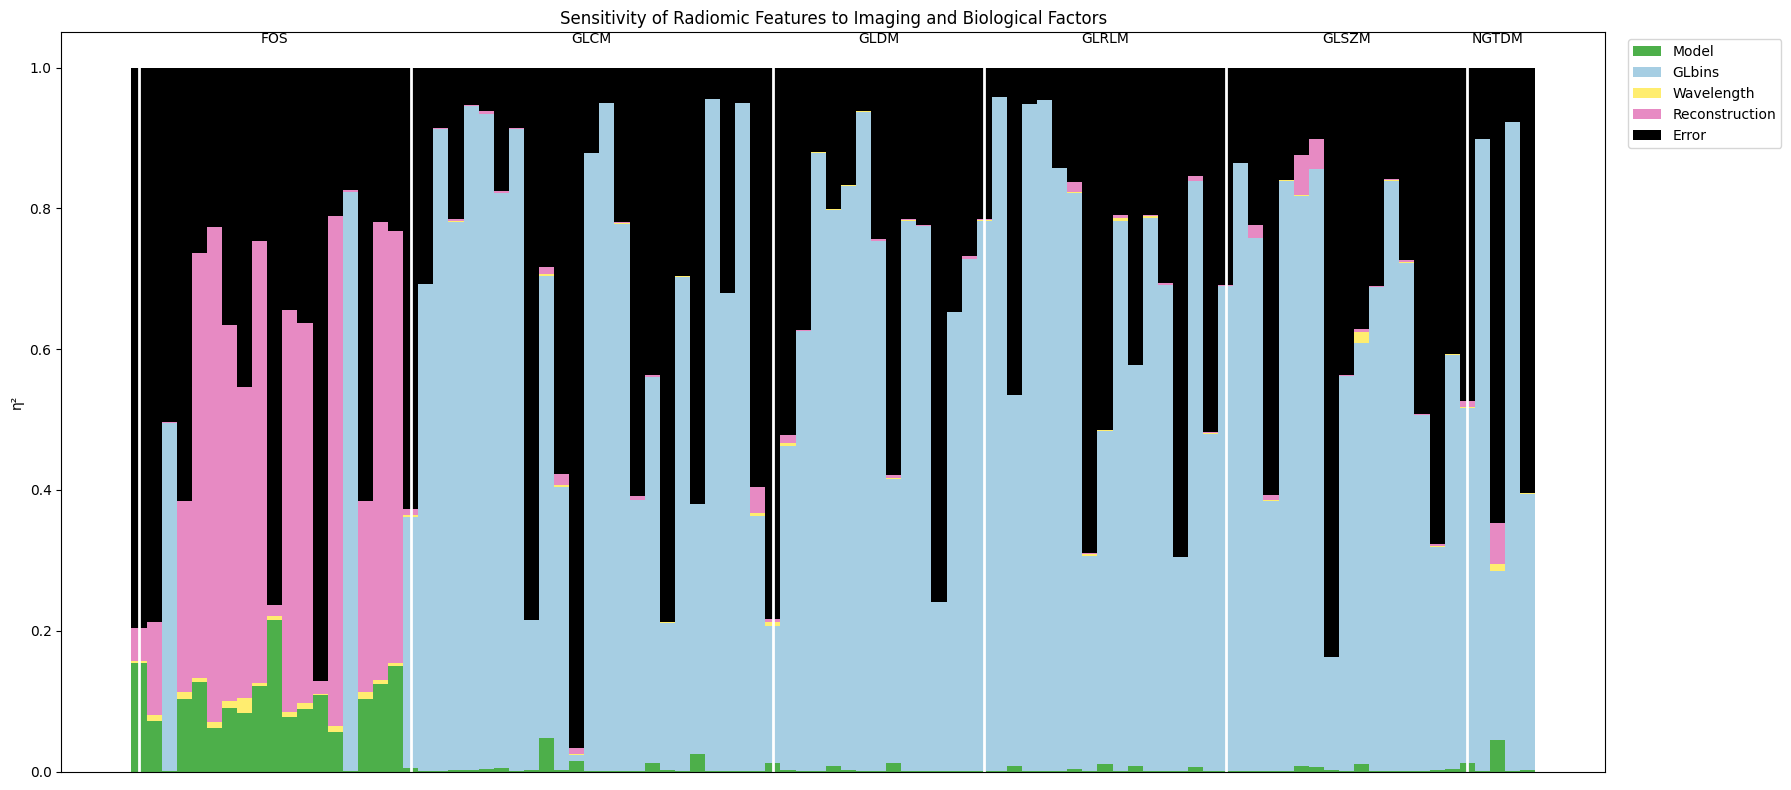

In [228]:
import matplotlib.pyplot as plt
import numpy as np

# Define consistent color mapping from the paper
color_map = {
    "Model": "#4daf4a",          # green
    "GLbins": "#a6cee3",         # light blue
    "Wavelength": "#ffed6f",     # yellow
    "Reconstruction": "#e78ac3", # pink
    "Error": "#000000"           # black
}

# Sort by feature group for aesthetics (optional)
def get_feature_group(feature):
    feature = feature.lower()
    if "fo " in feature: return "FOS"
    if "glcm" in feature: return "GLCM"
    if "gldm" in feature: return "GLDM"
    if "glrlm" in feature: return "GLRLM"
    if "glszm" in feature: return "GLSZM"
    if "ngtdm" in feature: return "NGTDM"
    return "Other"

eta2_df["Group"] = eta2_df.index.map(get_feature_group)
eta2_sorted = eta2_df.sort_values("Group")

# Plot
fig, ax = plt.subplots(figsize=(18, 8))
bottom = np.zeros(len(eta2_sorted))

ordered_factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]
for factor in ordered_factors:
    ax.bar(
        x=np.arange(len(eta2_sorted)),
        height=eta2_sorted[factor],
        bottom=bottom,
        color=color_map[factor],
        width=1.0,
        label=factor
    )
    bottom += eta2_sorted[factor].values

# Draw white lines between groups
group_change_idx = eta2_sorted["Group"].ne(eta2_sorted["Group"].shift()).to_numpy().nonzero()[0]
for idx in group_change_idx:
    ax.axvline(idx, color="white", linewidth=2)

# Add group labels above bars
group_midpoints = []
prev = 0
for idx in list(group_change_idx[1:]) + [len(eta2_sorted)]:
    mid = (prev + idx) // 2
    group_midpoints.append(mid)
    prev = idx

group_names = eta2_sorted["Group"].drop_duplicates().tolist()
for x, label in zip(group_midpoints, group_names):
    ax.text(x, 1.03, label, ha="center", va="bottom", fontsize=10)

# Final formatting
ax.set_ylabel("η²")
ax.set_ylim(0, 1.05)
ax.set_xticks([])
ax.set_title("Sensitivity of Radiomic Features to Imaging and Biological Factors")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


## ANOVA - Uncorrected Features Used

In [168]:
# Folder with your 12 raw radiomic .csv files
folder = "data/ModelsUncorrected"  # <- adjust to your actual path
files = sorted([f for f in os.listdir(folder) if f.endswith(".csv")])

df_list = []

for f in files:
    df = pd.read_csv(os.path.join(folder, f))
    df["Reconstruction"] = "MB" if "_MB" in f else "BP"
    df_list.append(df)

df_combined_raw = pd.concat(df_list, ignore_index=True)


In [169]:
for col in ["Model", "Wavelength", "GLbins", "Reconstruction"]:
    df_combined_raw[col] = df_combined_raw[col].astype("category")


In [170]:
print(df_combined_raw.shape)           # Should be (2268, ~150)
print(df_combined_raw.columns[:10])    # Should include 'original_firstorder_Skewness', etc.


(2268, 135)
Index(['PatientName', 'GLbins', 'Model', 'Wavelength', 'SliceThickness',
       'diagnostics_Versions_PyRadiomics', 'diagnostics_Versions_Numpy',
       'diagnostics_Versions_SimpleITK', 'diagnostics_Versions_PyWavelet',
       'diagnostics_Versions_Python'],
      dtype='object')


In [171]:
df_combined_raw.head(10)  # Check the first few rows

,PatientName,GLbins,Model,Wavelength,SliceThickness,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,Reconstruction
0,10,128,basal,700,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000723,8.287153,0.082252,30322.247767,0.649439,0.000213,9857.477189,0.011104,5.653971,BP
1,10,128,basal,730,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000511,8.262541,0.074904,39302.640799,0.613472,0.000216,9090.936807,0.010184,5.597988,BP
2,10,128,basal,750,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000613,8.233450,0.085048,31048.076320,0.680027,0.000209,9797.183512,0.011258,5.547308,BP
3,10,128,basal,760,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000508,8.243469,0.080132,34109.259779,0.648330,0.000207,9433.435006,0.010615,5.514328,BP
4,10,128,basal,770,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000545,8.289546,0.079658,28919.552993,0.631979,0.000218,9379.392808,0.010543,5.812234,BP
5,10,128,basal,800,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000532,8.241298,0.090044,21568.610169,0.673978,0.000228,10549.423196,0.012393,5.877830,BP
6,10,128,basal,820,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000551,8.232830,0.097230,15288.942008,0.698015,0.000233,11136.074576,0.013776,5.846847,BP
7,10,128,basal,840,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000651,8.229362,0.106748,11234.245575,0.741386,0.000229,11874.865835,0.015523,5.701993,BP
8,10,128,basal,850,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000577,8.210248,0.101803,14924.005725,0.728610,0.000231,11387.945642,0.014590,5.828971,BP
9,104,128,basal,700,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000408,8.191626,0.354548,30.809563,0.745655,0.000184,18360.556809,0.072772,1.409436,BP


In [172]:
df_combined_raw["Model"] = df_combined_raw["Model"].str.capitalize()
df_combined_raw["Model"] = df_combined_raw["Model"].astype("category")
df_combined_raw.head(10)  # Check the first few rows

,PatientName,GLbins,Model,Wavelength,SliceThickness,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,Reconstruction
0,10,128,Basal,700,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000723,8.287153,0.082252,30322.247767,0.649439,0.000213,9857.477189,0.011104,5.653971,BP
1,10,128,Basal,730,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000511,8.262541,0.074904,39302.640799,0.613472,0.000216,9090.936807,0.010184,5.597988,BP
2,10,128,Basal,750,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000613,8.233450,0.085048,31048.076320,0.680027,0.000209,9797.183512,0.011258,5.547308,BP
3,10,128,Basal,760,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000508,8.243469,0.080132,34109.259779,0.648330,0.000207,9433.435006,0.010615,5.514328,BP
4,10,128,Basal,770,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000545,8.289546,0.079658,28919.552993,0.631979,0.000218,9379.392808,0.010543,5.812234,BP
5,10,128,Basal,800,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000532,8.241298,0.090044,21568.610169,0.673978,0.000228,10549.423196,0.012393,5.877830,BP
6,10,128,Basal,820,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000551,8.232830,0.097230,15288.942008,0.698015,0.000233,11136.074576,0.013776,5.846847,BP
7,10,128,Basal,840,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000651,8.229362,0.106748,11234.245575,0.741386,0.000229,11874.865835,0.015523,5.701993,BP
8,10,128,Basal,850,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000577,8.210248,0.101803,14924.005725,0.728610,0.000231,11387.945642,0.014590,5.828971,BP
9,104,128,Basal,700,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000408,8.191626,0.354548,30.809563,0.745655,0.000184,18360.556809,0.072772,1.409436,BP


In [374]:
df_combined_raw

meta_cols = ["PatientName", "Model", "GLbins", "Wavelength", "Reconstruction"]

# feature_names_93 already contains the correct 93 feature column names (like 'FO Skewness', etc.)
final_cols = feature_cols + meta_cols

df_combined_raw = df_combined_raw[final_cols]
print(df_combined_raw.shape)

(2268, 98)


In [373]:
len(final_cols)

98

In [173]:
# Identify luminal patients
luminal_patients = df_combined_raw[df_combined_raw["Model"] == "Luminal"]["PatientName"].unique()
print("Luminal patients:", luminal_patients)

# Drop one (paper says it was randomly selected)
drop_patient = luminal_patients[0]  # or choose randomly
df_balanced = df_combined_raw[df_combined_raw["PatientName"] != drop_patient]
print("New shape:", df_balanced.shape)  # Should be (2160, ...)


Luminal patients: [144 163 176 183 188 193 198 199 217 223 246]
New shape: (2160, 135)


<Axes: xlabel='Model'>

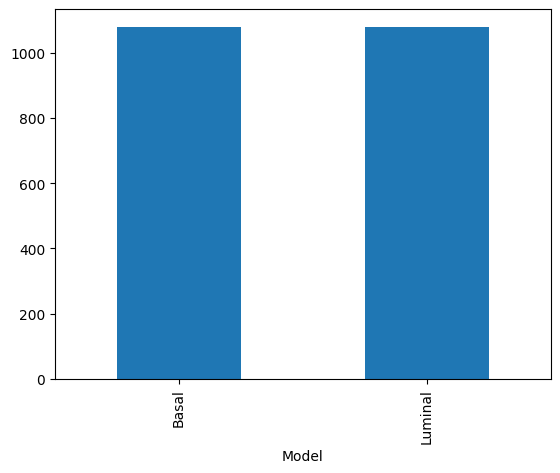

In [174]:
df_balanced["Model"].value_counts().plot(kind="bar")

In [175]:
df_balanced

,PatientName,GLbins,Model,Wavelength,SliceThickness,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,Reconstruction
0,10,128,Basal,700,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000723,8.287153,0.082252,3.032225e+04,0.649439,0.000213,9857.477189,0.011104,5.653971,BP
1,10,128,Basal,730,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000511,8.262541,0.074904,3.930264e+04,0.613472,0.000216,9090.936807,0.010184,5.597988,BP
2,10,128,Basal,750,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000613,8.233450,0.085048,3.104808e+04,0.680027,0.000209,9797.183512,0.011258,5.547308,BP
3,10,128,Basal,760,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000508,8.243469,0.080132,3.410926e+04,0.648330,0.000207,9433.435006,0.010615,5.514328,BP
4,10,128,Basal,770,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.000545,8.289546,0.079658,2.891955e+04,0.631979,0.000218,9379.392808,0.010543,5.812234,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,98,8,Basal,770,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.059403,5.695567,0.001681,3.469996e+07,286.869851,0.000104,6.681988,0.002877,0.005507,MB
2264,98,8,Basal,800,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.054958,5.837062,0.002024,2.507926e+07,310.723250,0.000111,6.738676,0.003780,0.005968,MB
2265,98,8,Basal,820,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.076501,5.887541,0.002203,2.413289e+07,308.923560,0.000117,6.501626,0.003656,0.006386,MB
2266,98,8,Basal,840,1.0,v3.0.1,1.19.5,2.0.1,1.1.1,3.6.9,...,0.061871,5.987187,0.002179,2.256604e+07,306.856707,0.000115,6.690178,0.004198,0.005954,MB


In [176]:
df_corrected = pd.read_csv("data/All_features_corrected_final_patient.csv")
feature_names_93 = df_corrected.columns.drop("PatientName").tolist()

print(f"Filtered feature count: {len(feature_names_93)}")

Filtered feature count: 93


In [177]:
 def reverse_feature_name(corrected_name):
    mapping = {
        "FO": "original_firstorder",
        "GLCM": "original_glcm",
        "GLDM": "original_gldm",
        "GLRLM": "original_glrlm",
        "GLSZM": "original_glszm",
        "NGTDM": "original_ngtdm",
        "Shape": "original_shape"
    }

    for prefix, raw_prefix in mapping.items():
        if corrected_name.startswith(prefix + " "):
            suffix = corrected_name[len(prefix)+1:]  # remove prefix and space
            return f"{raw_prefix}_{suffix}"
    return None


In [178]:
mapped_feature_names = [reverse_feature_name(name) for name in feature_names_93]
mapped_feature_names = [name for name in mapped_feature_names if name in df_balanced.columns]

print(f"Matched {len(mapped_feature_names)} features in raw dataset.")


Matched 93 features in raw dataset.


In [ ]:
feature_cols = mapped_feature_names



['original_firstorder_10Percentile',
 'original_firstorder_90Percentile',
 'original_firstorder_Energy',
 'original_firstorder_Entropy',
 'original_firstorder_InterquartileRange',
 'original_firstorder_Kurtosis',
 'original_firstorder_Maximum',
 'original_firstorder_MeanAbsoluteDeviation',
 'original_firstorder_Mean',
 'original_firstorder_Median',
 'original_firstorder_Minimum',
 'original_firstorder_Range',
 'original_firstorder_RobustMeanAbsoluteDeviation',
 'original_firstorder_RootMeanSquared',
 'original_firstorder_Skewness',
 'original_firstorder_TotalEnergy',
 'original_firstorder_Uniformity',
 'original_firstorder_Variance',
 'original_glcm_Autocorrelation',
 'original_glcm_ClusterProminence',
 'original_glcm_ClusterShade',
 'original_glcm_ClusterTendency',
 'original_glcm_Contrast',
 'original_glcm_Correlation',
 'original_glcm_DifferenceAverage',
 'original_glcm_DifferenceEntropy',
 'original_glcm_DifferenceVariance',
 'original_glcm_Id',
 'original_glcm_Idm',
 'original_glc

In [371]:
# Define metadata columns you want to keep
meta_cols = ["PatientName", "Model", "GLbins", "Wavelength", "Reconstruction"]

# feature_names_93 already contains the correct 93 feature column names (like 'FO Skewness', etc.)
final_cols = feature_cols + meta_cols

final_cols


['original_firstorder_10Percentile',
 'original_firstorder_90Percentile',
 'original_firstorder_Energy',
 'original_firstorder_Entropy',
 'original_firstorder_InterquartileRange',
 'original_firstorder_Kurtosis',
 'original_firstorder_Maximum',
 'original_firstorder_MeanAbsoluteDeviation',
 'original_firstorder_Mean',
 'original_firstorder_Median',
 'original_firstorder_Minimum',
 'original_firstorder_Range',
 'original_firstorder_RobustMeanAbsoluteDeviation',
 'original_firstorder_RootMeanSquared',
 'original_firstorder_Skewness',
 'original_firstorder_TotalEnergy',
 'original_firstorder_Uniformity',
 'original_firstorder_Variance',
 'original_glcm_Autocorrelation',
 'original_glcm_ClusterProminence',
 'original_glcm_ClusterShade',
 'original_glcm_ClusterTendency',
 'original_glcm_Contrast',
 'original_glcm_Correlation',
 'original_glcm_DifferenceAverage',
 'original_glcm_DifferenceEntropy',
 'original_glcm_DifferenceVariance',
 'original_glcm_Id',
 'original_glcm_Idm',
 'original_glc

In [181]:
df_balanced_clean = df_balanced[final_cols].copy()
print(df_balanced_clean.shape)  # Should be (2160, 93 + 6) = (2160, 99)


(2160, 98)


In [182]:
df_balanced_clean

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,PatientName,Model,GLbins,Wavelength,Reconstruction
0,69.142880,290.878683,4.448008e+09,4.636961,99.644165,23.988499,1506.465942,80.712806,167.184233,136.090408,...,0.649439,0.000213,9857.477189,0.011104,5.653971,10,Basal,128,700,BP
1,68.959734,246.576346,3.275936e+09,4.593670,80.613131,24.513340,1244.968140,64.953736,148.365253,123.751446,...,0.613472,0.000216,9090.936807,0.010184,5.597988,10,Basal,128,730,BP
2,70.308770,265.578290,3.766853e+09,4.614533,87.411236,24.715534,1360.987915,71.373395,156.751060,129.119141,...,0.680027,0.000209,9797.183512,0.011258,5.547308,10,Basal,128,750,BP
3,69.735306,273.831262,4.000455e+09,4.573273,91.426805,24.677900,1426.273926,74.664145,160.247312,131.045944,...,0.648330,0.000207,9433.435006,0.010615,5.514328,10,Basal,128,760,BP
4,68.767374,252.913724,3.433929e+09,4.613481,83.389416,24.597626,1282.152344,67.249362,150.974229,125.121998,...,0.631979,0.000218,9379.392808,0.010543,5.812234,10,Basal,128,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,992.082990,4457.898047,1.070236e+12,1.369536,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,2080.059937,...,286.869851,0.000104,6.681988,0.002877,0.005507,98,Basal,8,770,MB
2264,851.154541,4067.293140,8.697697e+11,1.501392,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,1894.330383,...,310.723250,0.000111,6.738676,0.003780,0.005968,98,Basal,8,800,MB
2265,838.989789,4029.269922,8.527069e+11,1.469264,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,1876.432617,...,308.923560,0.000117,6.501626,0.003656,0.006386,98,Basal,8,820,MB
2266,878.749854,4083.819263,8.834429e+11,1.551741,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,1926.486694,...,306.856707,0.000115,6.690178,0.004198,0.005954,98,Basal,8,840,MB


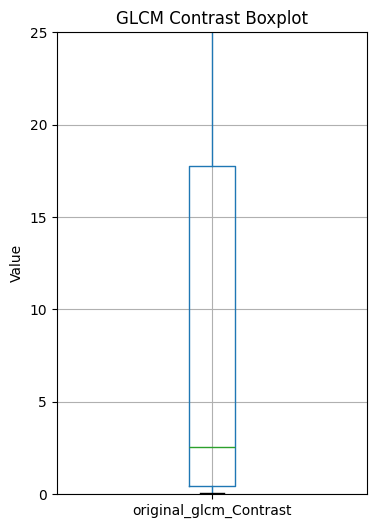

In [362]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 6))
df_balanced_clean.boxplot(column='original_glcm_Contrast', showfliers=True)
plt.ylim(0, 25)  # optional y-axis range
plt.title('GLCM Contrast Boxplot')
plt.ylabel('Value')
plt.grid(True)
plt.show()


In [183]:
for col in ["Model", "GLbins", "Wavelength", "Reconstruction"]:
    df_balanced_clean[col] = df_balanced_clean[col].astype("category")


In [184]:
# Example for Skewness
model = ols(f'Q("original_firstorder_Skewness") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)', data=df_balanced_clean).fit()
aov = sm.stats.anova_lm(model, typ=2)
ss_total = aov["sum_sq"].sum()
eta2 = aov["sum_sq"] / ss_total
print(eta2)

C(Model)             2.158304e-01
C(GLbins)            7.671903e-30
C(Wavelength)        5.470733e-03
C(Reconstruction)    1.509220e-02
Residual             7.636067e-01
Name: sum_sq, dtype: float64


In [185]:
# Example for Skewness
model = ols(f'Q("original_firstorder_Skewness") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)', data=df_balanced).fit()
aov = sm.stats.anova_lm(model, typ=2)
ss_total = aov["sum_sq"].sum()
eta2 = aov["sum_sq"] / ss_total
print(eta2)

C(Model)             2.158304e-01
C(GLbins)            7.671903e-30
C(Wavelength)        5.470733e-03
C(Reconstruction)    1.509220e-02
Residual             7.636067e-01
Name: sum_sq, dtype: float64


In [186]:
# Exclude metadata columns — keep only radiomic features
meta_cols = ["PatientName", "Model", "GLbins", "Wavelength", "Reconstruction"]

print(f"Total features: {len(feature_cols)}")


Total features: 93


In [188]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from tqdm import tqdm
import numpy as np

eta2_list = []

for feature in tqdm(feature_cols):
    try:
        formula = f'Q("{feature}") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)'
        model = ols(formula, data=df_balanced).fit()
        aov_table = sm.stats.anova_lm(model, typ=2)

        # η² = sum_sq_factor / total_sum_sq
        ss_total = aov_table["sum_sq"].sum()
        eta2 = (aov_table["sum_sq"] / ss_total).to_dict()
        eta2["Feature"] = feature

        eta2_list.append(eta2)
    except Exception as e:
        print(f"Error on {feature}: {e}")


100%|██████████| 93/93 [00:01<00:00, 78.08it/s]


In [189]:
eta2_df = pd.DataFrame(eta2_list).fillna(0).set_index("Feature")
eta2_df = eta2_df.rename(columns={"Residual": "Error"})

# Clean up column names like C(Model) → Model
eta2_df.columns = eta2_df.columns.str.replace(r"C\((.*?)\)", r"\1", regex=True)

# Ensure proper order of factors
eta2_df = eta2_df[["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]]

eta2_df.head(10)


,Model,GLbins,Wavelength,Reconstruction,Error
Feature,,,,,
original_firstorder_10Percentile,0.153465,4.365468e-31,0.003007,0.047951,0.795577
original_firstorder_90Percentile,0.123733,3.228577e-30,0.005765,0.651656,0.218846
original_firstorder_Energy,0.145717,9.708694e-31,0.009443,0.234996,0.609844
original_firstorder_Entropy,0.004220,9.327987e-01,0.000163,0.003136,0.059683
original_firstorder_InterquartileRange,0.055742,3.015706e-30,0.008758,0.724673,0.210826
original_firstorder_Kurtosis,0.108770,7.797270e-30,0.001080,0.018924,0.871227
original_firstorder_Maximum,0.089419,2.145480e-30,0.007508,0.540806,0.362266
original_firstorder_MeanAbsoluteDeviation,0.076944,2.219214e-30,0.007538,0.571736,0.343782
original_firstorder_Mean,0.150334,3.073176e-30,0.003939,0.612866,0.232862


In [190]:
eta2_df['Model'].sort_values(ascending=False).head(10)

Feature
original_ngtdm_Coarseness                0.316549
original_firstorder_Skewness             0.215830
original_firstorder_10Percentile         0.153465
original_firstorder_Mean                 0.150334
original_firstorder_Energy               0.145717
original_firstorder_TotalEnergy          0.145717
original_firstorder_RootMeanSquared      0.127830
original_firstorder_90Percentile         0.123733
original_firstorder_Median               0.122155
original_glrlm_GrayLevelNonUniformity    0.114695
Name: Model, dtype: float64

In [191]:
import matplotlib.pyplot as plt
import numpy as np

# Feature group assignment based on name
def get_feature_group(name):
    name = name.lower()
    if "firstorder" in name: return "FOS"
    if "glcm" in name: return "GLCM"
    if "gldm" in name: return "GLDM"
    if "glrlm" in name: return "GLRLM"
    if "glszm" in name: return "GLSZM"
    if "ngtdm" in name: return "NGTDM"
    if "shape" in name: return "SHAPE"
    return "Other"

eta2_df["Group"] = eta2_df.index.map(get_feature_group)

# Paper-style color map
color_map = {
    "Model": "#4daf4a",          # Green
    "GLbins": "#a6cee3",         # Light blue
    "Wavelength": "#ffed6f",     # Yellow
    "Reconstruction": "#e78ac3", # Pink
    "Error": "#000000"           # Black
}


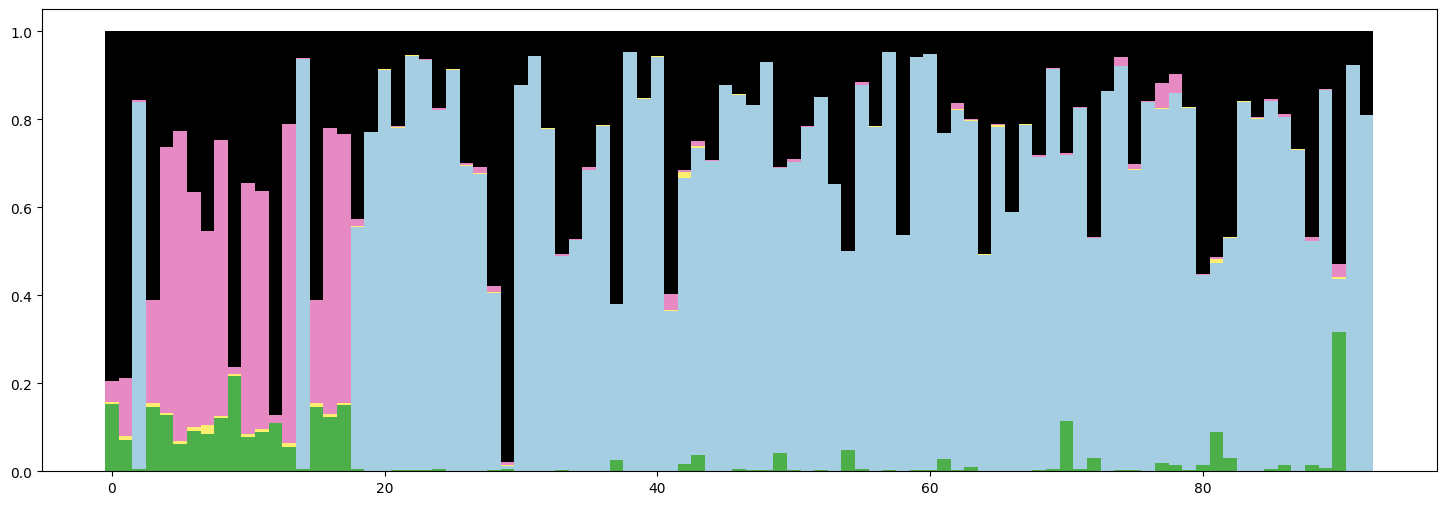

In [192]:
# Sort by feature group
eta2_sorted = eta2_df.sort_values("Group")

fig, ax = plt.subplots(figsize=(18, 6))

bottom = np.zeros(len(eta2_sorted))
ordered_factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]

# Plot stacked bars
for factor in ordered_factors:
    ax.bar(
        x=np.arange(len(eta2_sorted)),
        height=eta2_sorted[factor],
        bottom=bottom,
        color=color_map[factor],
        width=1.0,
        label=factor
    )
    bottom += eta2_sorted[factor].values


## Violin Plots

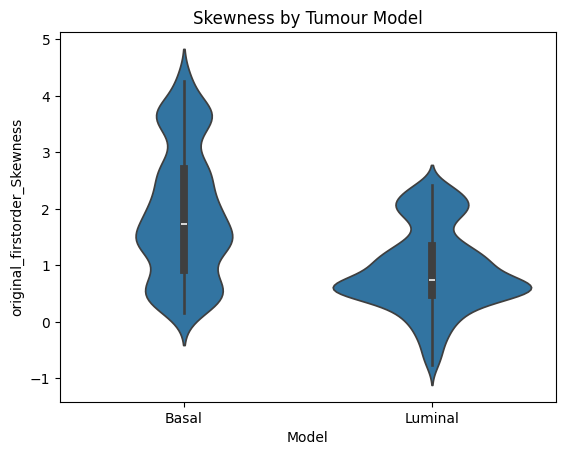

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(
    data=df_balanced,
    x="Model",
    y="original_firstorder_Skewness"
)
plt.title("Skewness by Tumour Model")
plt.show()



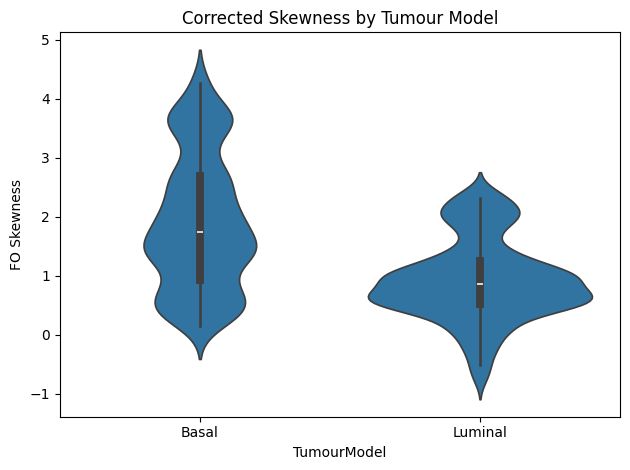

In [65]:
df_corrected = pd.read_csv("data/All_features_corrected_final.csv")
labels = pd.read_csv("data/All_model.csv", header=None, names=["TumourModel"])
df_corrected["TumourModel"] = labels.iloc[1:].reset_index(drop=True)["TumourModel"]  # skip header row
df_corrected["TumourModel"] = df_corrected["TumourModel"].str.capitalize().astype("category")

sns.violinplot(
    data=df_corrected,
    x="TumourModel",
    y="FO Skewness"
)
plt.title("Corrected Skewness by Tumour Model")
plt.tight_layout()
plt.show()


## Manual ANOVA calc

In [91]:
df_corrected = pd.read_csv("data/All_features_corrected_final_patient.csv")
df_corrected["PatientName"] = df_corrected["PatientName"].astype(str)


In [92]:
import os

folder = "data/ModelsUncorrected"  # update this
files = sorted([f for f in os.listdir(folder) if f.endswith(".csv")])

metadata_list = []
for f in files:
    df = pd.read_csv(os.path.join(folder, f), usecols=["PatientName", "Model", "Wavelength", "GLbins"])
    df["Reconstruction"] = "Model Linear +" if "_MB" in f else "Backprojection"
    df["PatientName"] = df["PatientName"].astype(str)
    metadata_list.append(df)

df_metadata = pd.concat(metadata_list, ignore_index=True)


In [93]:
df_combined = pd.concat([df_corrected, df_metadata.drop(columns="PatientName")], axis=1)


In [94]:
df_combined

,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,GLbins,Model,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,128,basal,700,Backprojection
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,128,basal,730,Backprojection
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,128,basal,750,Backprojection
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,128,basal,760,Backprojection
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,128,basal,770,Backprojection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,98,992.082990,4457.898047,9.779358e+06,314845.586861,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,...,0.000031,96.333320,9.712949e+05,82287.526364,-0.001564,1.369483e+16,8,basal,770,Model Linear +
2264,98,851.154541,4067.293140,8.219187e+06,347907.061977,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,...,0.000031,96.332213,1.128664e+06,105620.991383,0.000838,1.634342e+16,8,basal,800,Model Linear +
2265,98,838.989789,4029.269922,8.086392e+06,353231.076936,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,...,0.000031,96.335268,1.169228e+06,104233.632403,0.001966,1.582569e+16,8,basal,820,Model Linear +
2266,98,878.749854,4083.819263,8.325601e+06,363272.297324,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,...,0.000031,96.333182,1.179483e+06,110186.114695,0.003280,1.493451e+16,8,basal,840,Model Linear +


In [95]:
for col in ["Model", "Wavelength", "GLbins", "Reconstruction"]:
    if df_combined[col].dtype == object:
        df_combined[col] = df_combined[col].str.capitalize()
    df_combined[col] = df_combined[col].astype("category")

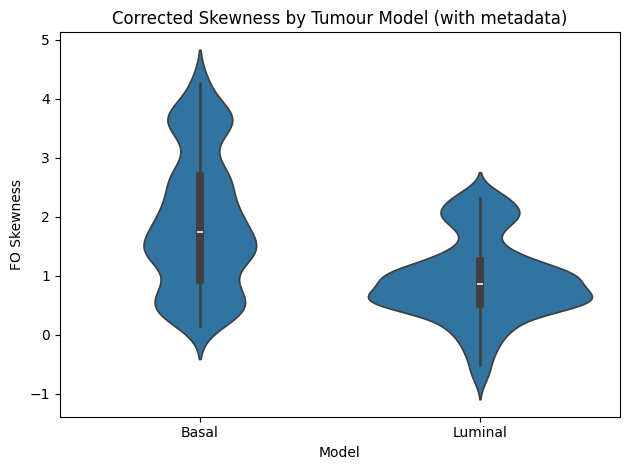

In [96]:
sns.violinplot(
    data=df_combined,
    x="Model",
    y="FO Skewness"
)
plt.title("Corrected Skewness by Tumour Model (with metadata)")
plt.tight_layout()
plt.show()


In [97]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols('Q("FO Skewness") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)', data=df_combined).fit()
aov = sm.stats.anova_lm(model, typ=2)
eta2 = aov["sum_sq"] / aov["sum_sq"].sum()
print(eta2)


C(Model)             2.211613e-01
C(GLbins)            6.183847e-30
C(Wavelength)        5.390232e-03
C(Reconstruction)    1.476156e-02
Residual             7.586869e-01
Name: sum_sq, dtype: float64


In [208]:
import numpy as np
import pandas as pd
from itertools import combinations
from collections import defaultdict

def manual_anova_decomposition(y, factors_df, factor_names=None):
    """
    Manual full-factorial ANOVA decomposition, replicating MATLAB's manualAnova2.
    Parameters:
        y: array-like, 1D response variable
        factors_df: DataFrame of categorical factors (e.g., Model, GLbins, ...)
        factor_names: optional list of factor names for labeling
    Returns:
        eta2_dict: Dict of eta squared values for each main effect and interaction
    """

    N = len(y)
    y = np.array(y)
    grand_mean = y.mean()
    ss_total = np.sum((y - grand_mean)**2)
    factor_labels = [pd.Categorical(factors_df[col]).codes for col in factors_df.columns]
    num_factors = len(factor_labels)
    factor_names = factor_names or list(factors_df.columns)

    ss_table = defaultdict(float)
    term_map = {}

    for order in range(1, num_factors + 1):
        for idx_tuple in combinations(range(num_factors), order):
            # Create interaction key
            key = "x".join([factor_names[i] for i in idx_tuple])

            # Compress labels into single interaction index
            interaction_index = np.zeros(N, dtype=int)
            multiplier = 1
            for i in reversed(idx_tuple):
                interaction_index += factor_labels[i] * multiplier
                multiplier *= (max(factor_labels[i]) + 1)

            # Compute group means
            group_means = {}
            for val in np.unique(interaction_index):
                mask = interaction_index == val
                group_means[val] = y[mask].mean()

            # Sum of squares for this interaction
            ss = sum(
                np.sum(interaction_index == k) * (mean_k - grand_mean) ** 2
                for k, mean_k in group_means.items()
            )

            # Subtract lower-order interactions
            to_subtract = 0
            for lower_order in range(1, order):
                for lower_tuple in combinations(idx_tuple, lower_order):
                    lower_key = "x".join([factor_names[i] for i in lower_tuple])
                    to_subtract += ss_table[lower_key]

            ss_table[key] = ss - to_subtract
            term_map[key] = idx_tuple

    # Compute residual SS
    ss_explained = sum(ss_table.values())
    ss_table["Error"] = ss_total - ss_explained

    # Normalize to get η²
    eta2_dict = {k: v / ss_total for k, v in ss_table.items()}
    return eta2_dict


In [212]:
# Columns for ANOVA
factors = ["Model", "GLbins", "Wavelength", "Reconstruction"]
feature = "FO Skewness"  # or any other feature from the 93

# Run manual ANOVA
eta2 = manual_anova_decomposition(
    y=df_combined_balanced[feature],
    factors_df=df_combined_balanced[factors],
    factor_names=factors
)

# Pretty print
import pprint
pprint.pprint(eta2)


{'Error': np.float64(0.7533592935394826),
 'GLbins': np.float64(0.0),
 'GLbinsxReconstruction': np.float64(-2.2818414246379698e-17),
 'GLbinsxWavelength': np.float64(-3.565377225996828e-18),
 'GLbinsxWavelengthxReconstruction': np.float64(3.9932224931164474e-17),
 'Model': np.float64(0.21583035694295755),
 'ModelxGLbins': np.float64(9.127365698551879e-17),
 'ModelxGLbinsxReconstruction': np.float64(-4.5636828492759397e-17),
 'ModelxGLbinsxWavelength': np.float64(-9.127365698551879e-17),
 'ModelxGLbinsxWavelengthxReconstruction': np.float64(9.127365698551879e-17),
 'ModelxReconstruction': np.float64(0.0003740234576066825),
 'ModelxWavelength': np.float64(0.009396370097587908),
 'ModelxWavelengthxReconstruction': np.float64(0.00044753423974019517),
 'Reconstruction': np.float64(0.015092202169470686),
 'Wavelength': np.float64(0.005470733389789687),
 'WavelengthxReconstruction': np.float64(2.948616336468198e-05)}


/var/folders/th/p1bpkycd1lx_c6j9tvg1m21c0000gn/T/ipykernel_4198/865190007.py:38: RuntimeWarning: overflow encountered in scalar multiply
  multiplier *= (max(factor_labels[i]) + 1)


In [142]:
df_128 = df_combined[df_combined["GLbins"] == 128].copy()


In [143]:
df_128

,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,GLbins,Model,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,702116.533708,5.431388,-0.008386,-1.346671e+15,128,Basal,700,Backprojection
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,635045.201104,5.512007,-0.008424,-1.347603e+15,128,Basal,730,Backprojection
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,775115.290530,5.212363,-0.008415,-1.346064e+15,128,Basal,750,Backprojection
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,562043.917443,5.830865,-0.008369,-1.347809e+15,128,Basal,760,Backprojection
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,688475.202442,5.429985,-0.008394,-1.346774e+15,128,Basal,770,Backprojection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,98,992.082990,4457.898047,9.779358e+06,-268417.318498,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,...,0.002133,152.434981,205144.254007,6.681988,-0.008165,-2.947595e+15,128,Basal,770,Model linear +
374,98,851.154541,4067.293140,8.219187e+06,-251475.165819,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,...,0.001550,157.103998,324301.463992,6.738676,-0.007988,-2.946616e+15,128,Basal,800,Model linear +
375,98,838.989789,4029.269922,8.086392e+06,-255603.261319,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,...,0.001493,156.751730,424877.831302,6.501626,-0.008013,-2.945730e+15,128,Basal,820,Model linear +
376,98,878.749854,4083.819263,8.325601e+06,-245005.769388,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,...,0.001398,156.347169,386824.488933,6.690178,-0.007907,-2.946645e+15,128,Basal,840,Model linear +


In [146]:
feature = "FO Skewness"  # or any other feature from the 93`"
factors_df = df_128[["Model", "Wavelength", "Reconstruction"]]

eta2 = manual_anova_decomposition(
    y=df_128[feature],
    factors_df=factors_df,
    factor_names=["Model", "Wavelength", "Reconstruction"]
)

import pprint
pprint.pprint(eta2)


{'Error': np.float64(0.7493155886175626),
 'Model': np.float64(0.22116133281065237),
 'ModelxReconstruction': np.float64(0.00022779989596230797),
 'ModelxWavelength': np.float64(0.00858688918065227),
 'ModelxWavelengthxReconstruction': np.float64(0.0005070747172560141),
 'Reconstruction': np.float64(0.014761559566887426),
 'Wavelength': np.float64(0.00539023227310989),
 'WavelengthxReconstruction': np.float64(4.952293791712924e-05)}


In [147]:
feature = "FO Skewness"
factors_df = df_128[["Model", "Wavelength", "Reconstruction"]]

eta2 = manual_anova_decomposition(
    y=df_128[feature],
    factors_df=factors_df,
    factor_names=["Model", "Wavelength", "Reconstruction"]
)

import pprint
pprint.pprint(eta2)


{'Error': np.float64(0.7493155886175626),
 'Model': np.float64(0.22116133281065237),
 'ModelxReconstruction': np.float64(0.00022779989596230797),
 'ModelxWavelength': np.float64(0.00858688918065227),
 'ModelxWavelengthxReconstruction': np.float64(0.0005070747172560141),
 'Reconstruction': np.float64(0.014761559566887426),
 'Wavelength': np.float64(0.00539023227310989),
 'WavelengthxReconstruction': np.float64(4.952293791712924e-05)}


In [267]:
# Step 1: Load features
df_features = pd.read_csv("data/All_features_corrected_final_patient.csv").reset_index(drop=True)

# Step 2: Load and concat metadata files in correct order
folder = "data/ModelsUncorrected"
csv_files = sorted([f for f in os.listdir(folder) if f.endswith(".csv")])

metadata_list = []
for f in csv_files:
    df = pd.read_csv(os.path.join(folder, f), usecols=["PatientName", "Model", "Wavelength", "GLbins"])
    df["Reconstruction"] = "MB" if "_MB" in f else "BP"
    metadata_list.append(df)

df_metadata = pd.concat(metadata_list, ignore_index=True)
df_metadata = df_metadata.reset_index(drop=True)

# Step 3: Verify same number of rows
assert len(df_features) == len(df_metadata) == 2268, "Row count mismatch"

# Step 4: Concatenate by row index
df_combined = pd.concat([df_features, df_metadata], axis=1)

# Step 5: Convert to category
for col in ["Model", "Wavelength", "GLbins", "Reconstruction"]:
    df_combined[col] = df_combined[col].astype("category")

print("✅ Final combined shape:", df_combined.shape)
df_combined

# Find all columns including their actual name object (even if repeated)
cols = pd.Series(df_combined.columns)
duplicates = cols[cols.duplicated(keep=False)]
# print("Duplicate columns:\n", duplicates)

df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]


# Get all luminal patient IDs
luminal_ids = df_combined[df_combined["Model"] == "luminal"]["PatientName"].unique()

# Pick one randomly (or use a fixed ID for reproducibility)
np.random.seed(42)
drop_id = np.random.choice(luminal_ids, 1)[0]
print(f"Dropping Luminal patient: {drop_id}")

# Drop all rows for that patient
df_combined = df_combined[df_combined["PatientName"] != drop_id].reset_index(drop=True)
print("✅ Final combined shape after dropping patient:", df_combined.shape)

df_combined


✅ Final combined shape: (2268, 99)
Dropping Luminal patient: 198
✅ Final combined shape after dropping patient: (2160, 98)


,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,GLbins,Model,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,128,basal,700,BP
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,128,basal,730,BP
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,128,basal,750,BP
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,128,basal,760,BP
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,128,basal,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,98,992.082990,4457.898047,9.779358e+06,314845.586861,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,...,0.000031,96.333320,9.712949e+05,82287.526364,-0.001564,1.369483e+16,8,basal,770,MB
2156,98,851.154541,4067.293140,8.219187e+06,347907.061977,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,...,0.000031,96.332213,1.128664e+06,105620.991383,0.000838,1.634342e+16,8,basal,800,MB
2157,98,838.989789,4029.269922,8.086392e+06,353231.076936,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,...,0.000031,96.335268,1.169228e+06,104233.632403,0.001966,1.582569e+16,8,basal,820,MB
2158,98,878.749854,4083.819263,8.325601e+06,363272.297324,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,...,0.000031,96.333182,1.179483e+06,110186.114695,0.003280,1.493451e+16,8,basal,840,MB


In [268]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
from tqdm import tqdm

# Identify feature columns — assume all numeric except the known factor columns
factor_cols = ["Model", "GLbins", "Wavelength", "Reconstruction"]
non_feature_cols = factor_cols + ["PatientName"]
feature_cols = df_combined.drop(columns=non_feature_cols).select_dtypes(include="number").columns.tolist()

eta2_list = []

# Run Type II ANOVA for each feature
for feature in tqdm(feature_cols):
    try:
        formula = f'Q("{feature}") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)'
        model = ols(formula, data=df_combined).fit()
        aov_table = sm.stats.anova_lm(model, typ=2)

        # Compute eta squared
        ss_total = aov_table["sum_sq"].sum()
        eta2 = (aov_table["sum_sq"] / ss_total).to_dict()
        eta2["Feature"] = feature
        eta2_list.append(eta2)
    except Exception as e:
        print(f"Failed on {feature}: {e}")

# Assemble into DataFrame
eta2_df = pd.DataFrame(eta2_list).fillna(0).set_index("Feature")

# Rename residual to 'Error'
eta2_df = eta2_df.rename(columns={"Residual": "Error"})

# Clean factor names
eta2_df.columns = eta2_df.columns.str.replace(r"C\((.*?)\)", r"\1", regex=True)

# Reorder columns
ordered_cols = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]
eta2_df = eta2_df[[col for col in ordered_cols if col in eta2_df.columns]]

# Optional: Preview
print(eta2_df.head())


100%|██████████| 93/93 [00:01<00:00, 66.65it/s]

                          Model        GLbins  Wavelength  Reconstruction  \
Feature                                                                     
FO 10Percentile        0.139400  5.421752e-31    0.003012        0.063903   
FO 90Percentile        0.120263  2.942635e-30    0.006011        0.657665   
FO Energy              0.103399  2.688510e-30    0.010647        0.272663   
FO Entropy             0.000305  8.276296e-01    0.000099        0.002180   
FO InterquartileRange  0.058562  3.206828e-30    0.009093        0.721231   

                          Error  
Feature                          
FO 10Percentile        0.793685  
FO 90Percentile        0.216061  
FO Energy              0.613291  
FO Entropy             0.169787  
FO InterquartileRange  0.211114  


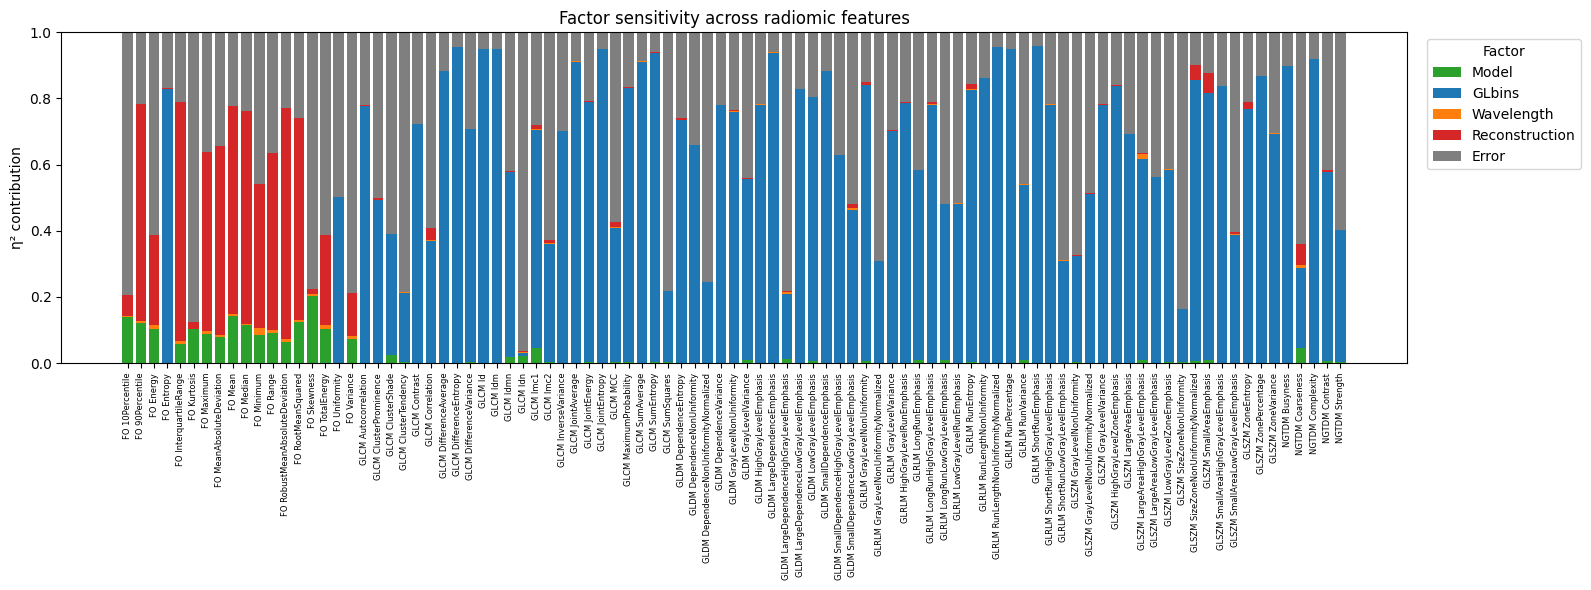

In [269]:
import matplotlib.pyplot as plt

# Ensure consistent order of factors and colors
plot_factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]
colors = {
    "Model": "#2ca02c",          # green
    "GLbins": "#1f77b4",         # blue
    "Wavelength": "#ff7f0e",     # orange
    "Reconstruction": "#d62728", # red
    "Error": "#7f7f7f"           # gray
}

# Reindex DataFrame just in case
eta2_df = eta2_df[plot_factors]

# Plot
fig, ax = plt.subplots(figsize=(16, 6))
bottom = pd.Series([0] * len(eta2_df), index=eta2_df.index)

for factor in plot_factors:
    ax.bar(eta2_df.index, eta2_df[factor], bottom=bottom, label=factor, color=colors[factor])
    bottom += eta2_df[factor]

# Aesthetics
ax.set_ylabel("η² contribution")
ax.set_title("Factor sensitivity across radiomic features")
ax.set_xticks(range(len(eta2_df)))
ax.set_xticklabels(eta2_df.index, rotation=90, fontsize=6)
ax.legend(title="Factor", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


### Standardisation Analysis (Marginal ANOVA Results)

In [270]:
def run_anova_on_subset(df, subset_condition, feature_cols, factors=["Model", "Wavelength", "GLbins", "Reconstruction"]):
    df_sub = df.query(subset_condition).copy()
    eta2_list = []

    for feature in tqdm(feature_cols):
        try:
            formula = f'Q("{feature}") ~ ' + ' + '.join([f'C({f})' for f in factors if f in df_sub.columns])
            model = ols(formula, data=df_sub).fit()
            aov = sm.stats.anova_lm(model, typ=2)
            ss_total = aov["sum_sq"].sum()
            eta2 = (aov["sum_sq"] / ss_total).to_dict()
            eta2["Feature"] = feature
            eta2_list.append(eta2)
        except Exception as e:
            print(f"⚠️ Failed on {feature}: {e}")

    eta2_df = pd.DataFrame(eta2_list)
    if "Feature" in eta2_df.columns:
        eta2_df = eta2_df.set_index("Feature")
    else:
        print("🚫 No features succeeded in ANOVA.")
        return pd.DataFrame()
    
    eta2_df = eta2_df.rename(columns={"Residual": "Error"})
    return eta2_df


def run_anova_fixed_glbin(df, glbin_value, feature_cols, factors=["Model", "Wavelength", "Reconstruction"]):
    df_sub = df[df["GLbins"] == glbin_value].copy()
    eta2_list = []

    for feature in tqdm(feature_cols, desc=f"GLbin {glbin_value}"):
        try:
            formula = f'Q("{feature}") ~ ' + ' + '.join([f'C({f})' for f in factors])
            model = ols(formula, data=df_sub).fit()
            aov = sm.stats.anova_lm(model, typ=2)
            ss_total = aov["sum_sq"].sum()
            eta2 = (aov["sum_sq"] / ss_total).to_dict()
            eta2["Feature"] = feature
            eta2_list.append(eta2)
        except Exception as e:
            print(f"⚠️ {feature} @ GLbin={glbin_value}: {e}")

    eta2_df = pd.DataFrame(eta2_list)
    if "Feature" in eta2_df.columns:
        eta2_df = eta2_df.set_index("Feature")
    eta2_df = eta2_df.rename(columns={"Residual": "Error"})

    # Clean column names
    eta2_df.columns = eta2_df.columns.str.replace(r"C\((.*?)\)", r"\1", regex=True)

    return eta2_df


In [271]:
glbin_values = sorted(df_combined["GLbins"].unique())
glbin_results = {}

for gl in glbin_values:
    glbin_results[gl] = run_anova_fixed_glbin(df_combined, glbin_value=gl, feature_cols=feature_cols)


GLbin 256: 100%|██████████| 93/93 [00:00<00:00, 203.04it/s]


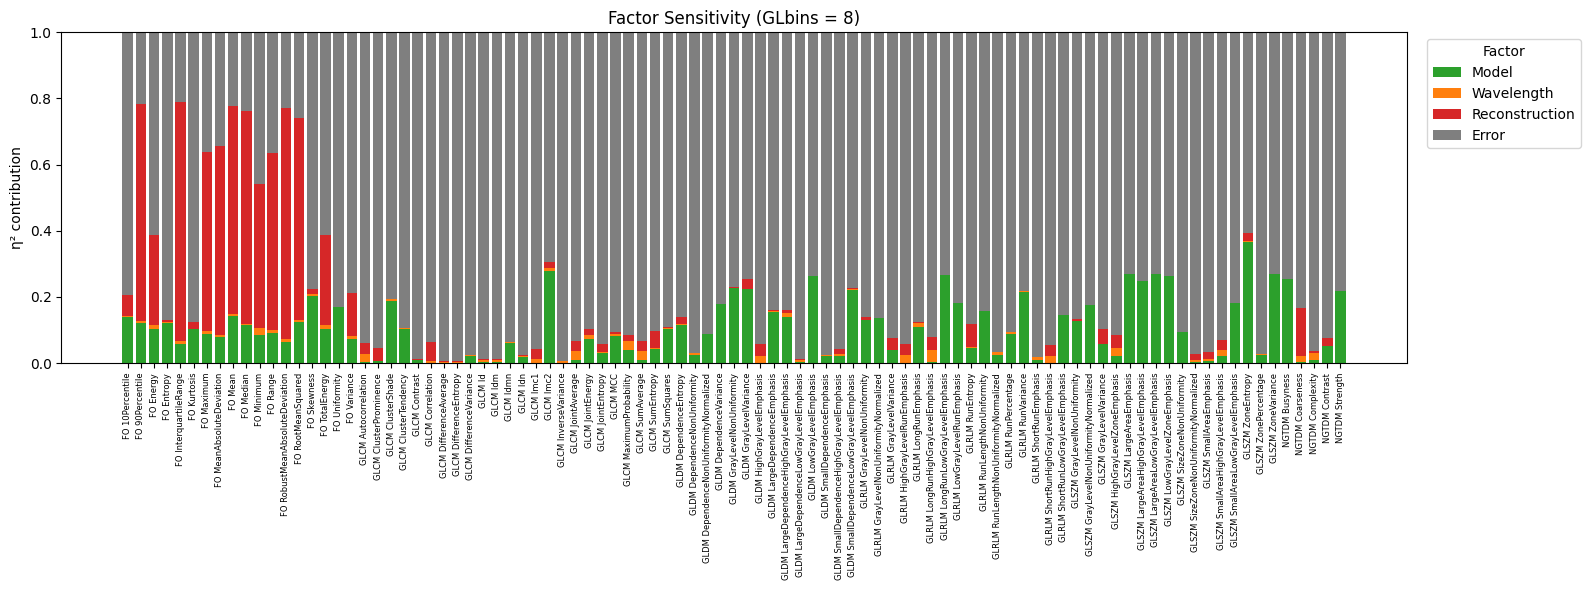

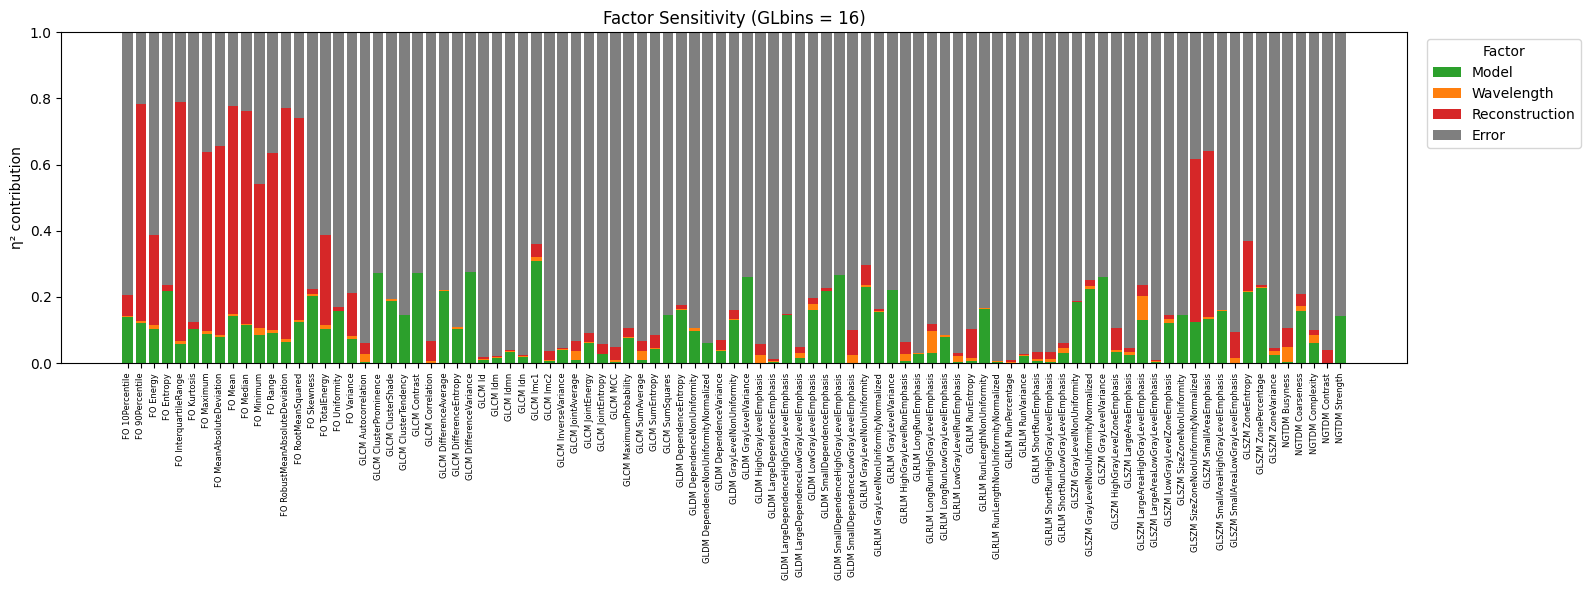

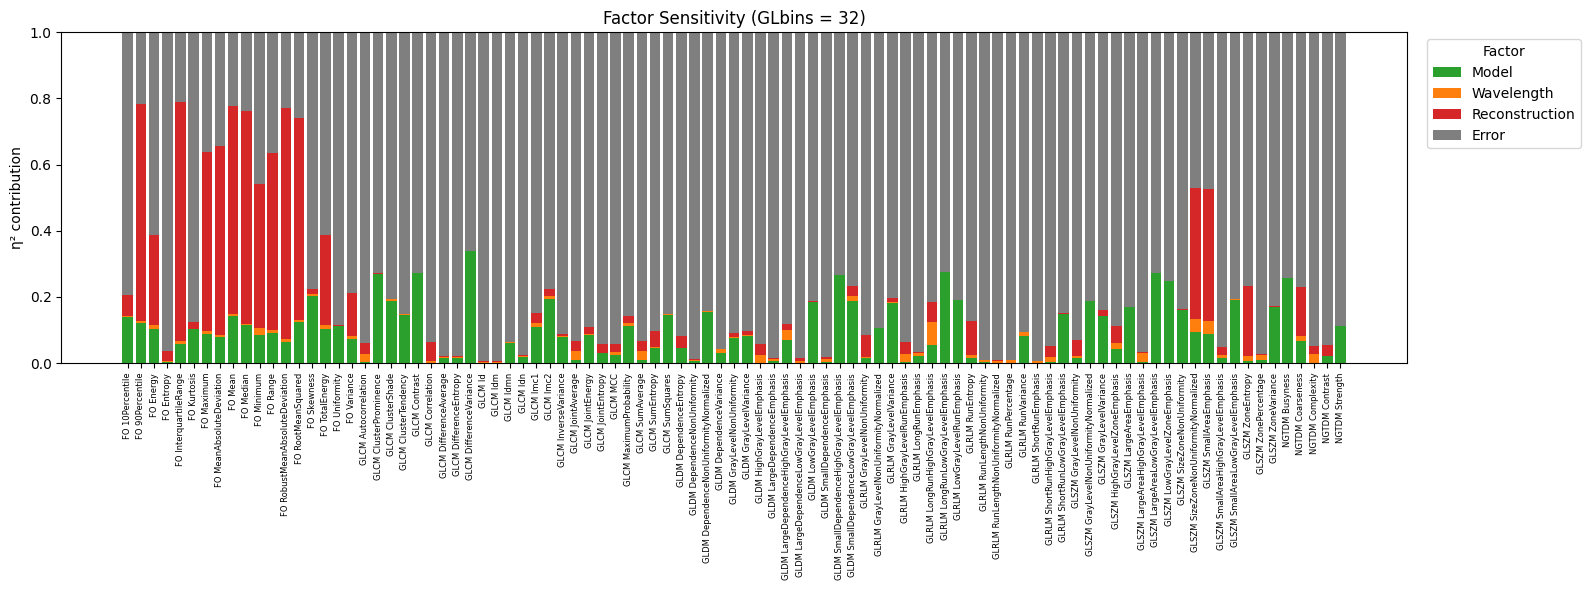

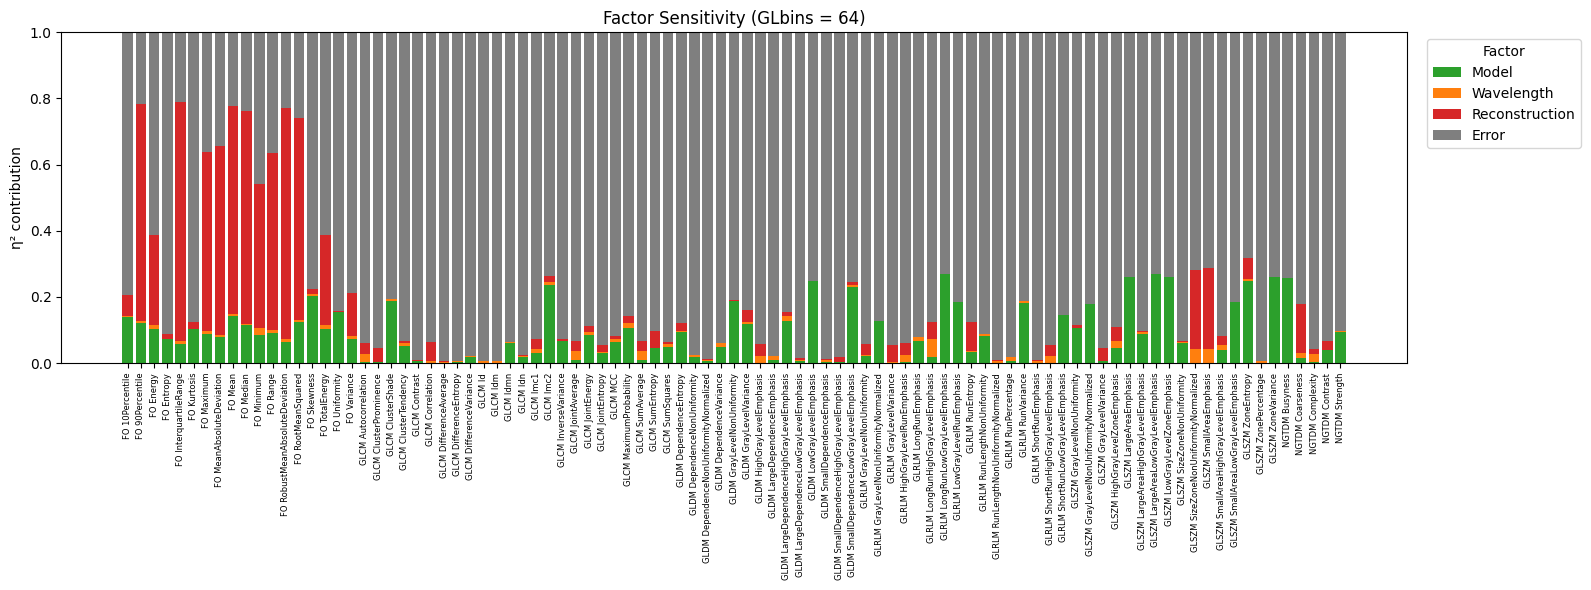

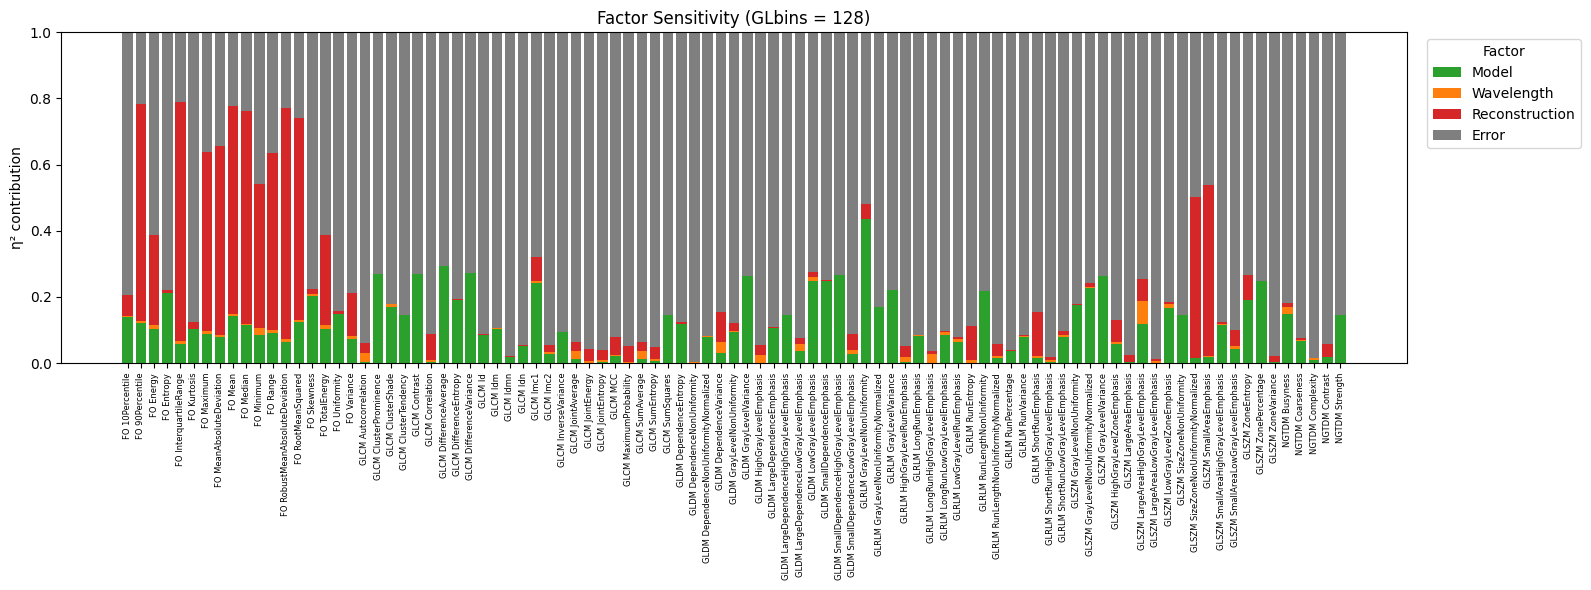

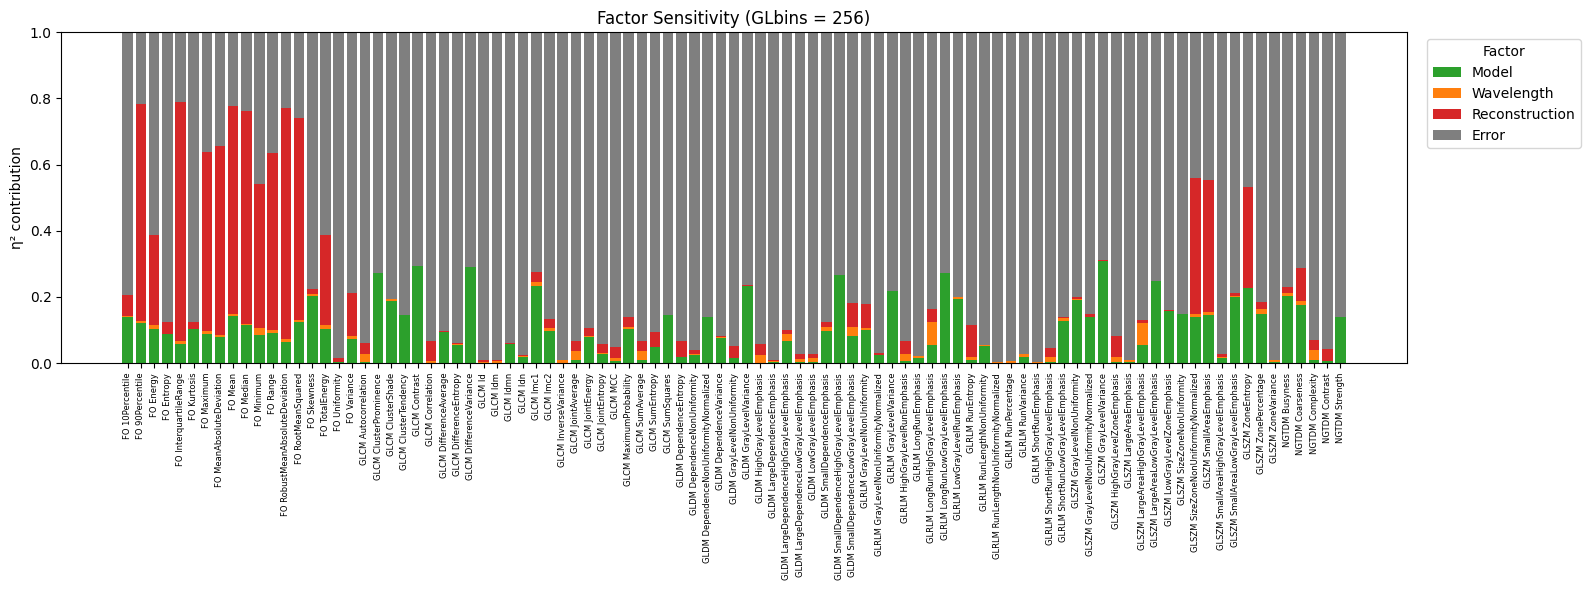

In [272]:
for gl, df_eta2 in glbin_results.items():
    plot_eta2_stacked(df_eta2, f"Factor Sensitivity (GLbins = {gl})")


In [273]:
# Define feature list
feature_cols = df_combined.drop(columns=["PatientName", "Model", "Wavelength", "GLbins", "Reconstruction"]).select_dtypes("number").columns.tolist()

# A.1. Standardise GLbins to 64
eta2_fixed_gl = run_anova_on_subset(df_combined, 'GLbins == 64', feature_cols)

# A.2. Standardise Reconstruction to 'MB'
eta2_fixed_recon = run_anova_on_subset(df_combined, 'Reconstruction == "MB"', feature_cols)


  0%|          | 0/93 [00:00<?, ?it/s]/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of c

In [274]:
print("Columns:", eta2_fixed_gl.columns.tolist())


Columns: ['C(Model)', 'C(Wavelength)', 'C(GLbins)', 'C(Reconstruction)', 'Error']


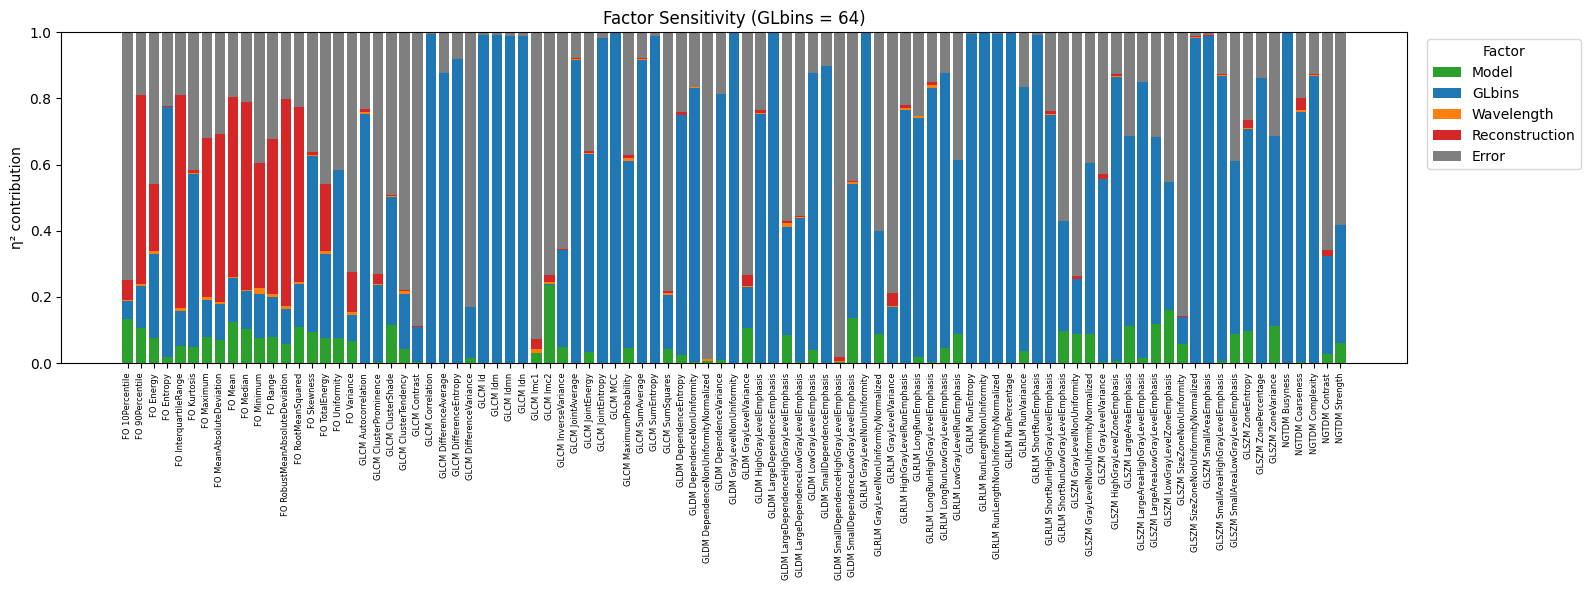

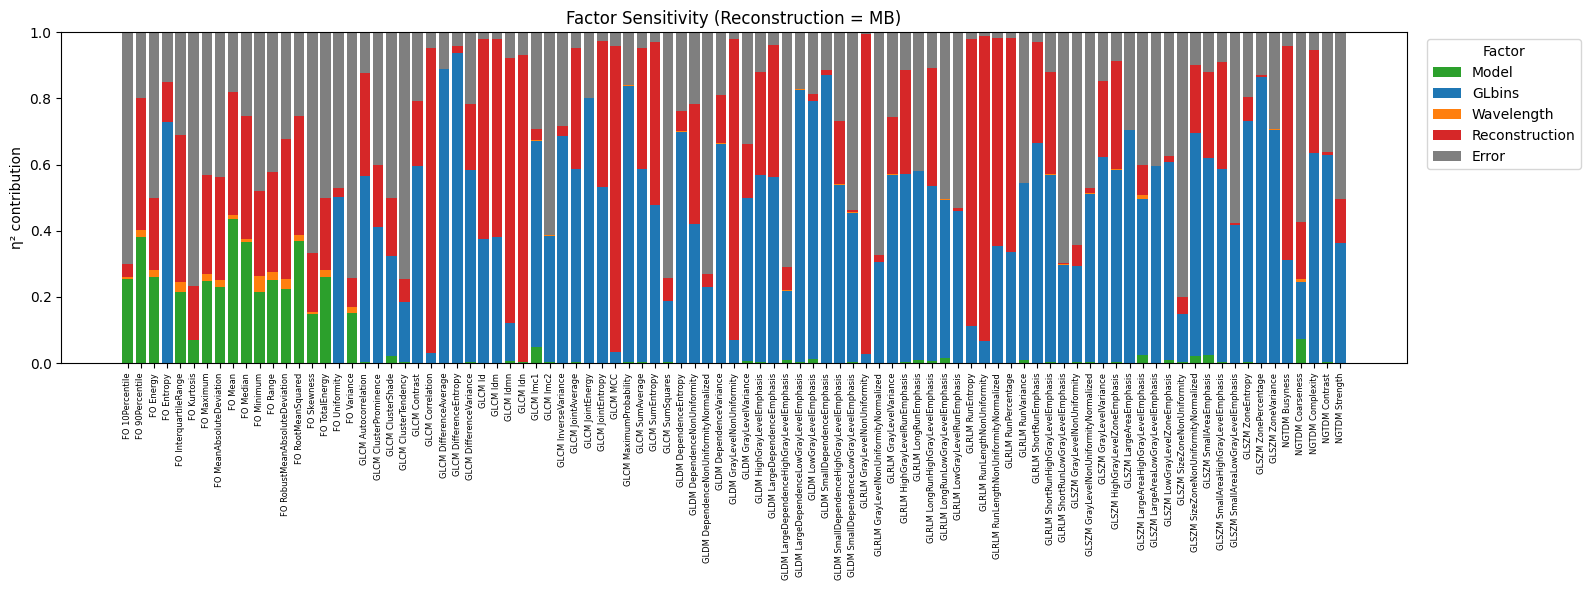

In [275]:

def plot_eta2_stacked(eta2_df, title):
    plot_factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]
    plot_factors = [col for col in plot_factors if col in eta2_df.columns]

    colors = {
        "Model": "#2ca02c",          # green
        "GLbins": "#1f77b4",         # blue
        "Wavelength": "#ff7f0e",     # orange
        "Reconstruction": "#d62728", # red
        "Error": "#7f7f7f"           # gray
    }

    fig, ax = plt.subplots(figsize=(16, 6))
    bottom = pd.Series([0] * len(eta2_df), index=eta2_df.index)

    for factor in plot_factors:
        ax.bar(eta2_df.index, eta2_df[factor], bottom=bottom, label=factor, color=colors[factor])
        bottom += eta2_df[factor]

    ax.set_ylabel("η² contribution")
    ax.set_title(title)
    ax.set_xticks(range(len(eta2_df)))
    ax.set_xticklabels(eta2_df.index, rotation=90, fontsize=6)
    ax.legend(title="Factor", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

# Plot both
eta2_fixed_gl.columns = eta2_fixed_gl.columns.str.replace(r"C\((.*?)\)", r"\1", regex=True)
eta2_fixed_recon.columns = eta2_fixed_recon.columns.str.replace(r"C\((.*?)\)", r"\1", regex=True)

plot_eta2_stacked(eta2_fixed_gl, "Factor Sensitivity (GLbins = 64)")
plot_eta2_stacked(eta2_fixed_recon, "Factor Sensitivity (Reconstruction = MB)")


### 5 Fold Analysis

In [262]:
import numpy as np
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

np.random.seed(42)

features_to_check = ["FO Skewness", "FO Kurtosis"]
factors = ["C(Model)", "C(Wavelength)", "C(GLbins)", "C(Reconstruction)", "Residual"]

# Storage structure: {feature: {factor: [η²_1, η²_2, ..., η²_5]}}
eta2_results = {feat: {f: [] for f in factors} for feat in features_to_check}

luminal_ids = df_combined[df_combined["Model"] == "luminal"]["PatientName"].unique()
basal_ids = df_combined[df_combined["Model"] == "basal"]["PatientName"].unique()

def get_eta2_all_factors(feature, df_sample):
    try:
        model = ols(f'Q("{feature}") ~ C(Model) + C(Wavelength) + C(GLbins) + C(Reconstruction)', data=df_sample).fit()
        aov = sm.stats.anova_lm(model, typ=2)
        ss_total = aov["sum_sq"].sum()
        return (aov["sum_sq"] / ss_total).to_dict()
    except Exception as e:
        print(f"⚠️ Failed ANOVA for {feature}: {e}")
        return None

for _ in range(5):
    sampled_ids = np.concatenate([
        np.random.choice(luminal_ids, size=8, replace=False),
        np.random.choice(basal_ids, size=8, replace=False)
    ])
    df_sample = df_combined[df_combined["PatientName"].isin(sampled_ids)]

    for feat in features_to_check:
        eta2 = get_eta2_all_factors(feat, df_sample)
        if eta2 is not None:
            for fac in factors:
                eta2_results[feat][fac].append(eta2.get(fac, np.nan))

# Now calculate mean, std, and CoV for each
summary_tables = {}
for feat in features_to_check:
    stats = {}
    for fac in factors:
        values = np.array(eta2_results[feat][fac])
        mean = np.nanmean(values)
        std = np.nanstd(values)
        cov = std / mean if mean != 0 else np.nan
        stats[fac.replace("C(", "").replace(")", "")] = {
            "mean": round(mean, 3),
            "std": round(std, 3),
            "CoV": round(cov, 2)
        }
    summary_tables[feat] = pd.DataFrame(stats).T

# Display both tables
print("📊 Skewness:")
display(summary_tables["FO Skewness"])

print("\n📊 Kurtosis:")
display(summary_tables["FO Kurtosis"])


📊 Skewness:


,mean,std,CoV
Model,0.219,0.027,0.12
Wavelength,0.005,0.001,0.29
GLbins,0.000,0.000,0.22
Reconstruction,0.014,0.002,0.12
Residual,0.762,0.024,0.03



📊 Kurtosis:


,mean,std,CoV
Model,0.129,0.017,0.13
Wavelength,0.001,0.000,0.43
GLbins,0.000,0.000,0.22
Reconstruction,0.018,0.003,0.17
Residual,0.852,0.015,0.02


In [337]:
def zscore_normalize_per_patient(df, feature_cols):
    df_norm = df.copy()
    for pid in df["PatientName"].unique():
        idx = df["PatientName"] == pid
        df_norm.loc[idx, feature_cols] = (
            df.loc[idx, feature_cols] - df.loc[idx, feature_cols].mean()
        ) / df.loc[idx, feature_cols].std()
    return df_norm


In [357]:
ordering = [
    "RadiomicsFeatures_21cases_8bins.csv",
    "RadiomicsFeatures_21cases_8bins_MB.csv",
    "RadiomicsFeatures_21cases_16bins.csv",
    "RadiomicsFeatures_21cases_16bins_MB.csv",
    "RadiomicsFeatures_21cases_32bins.csv",
    "RadiomicsFeatures_21cases_32bins_MB.csv",
    "RadiomicsFeatures_21cases_64bins.csv",
    "RadiomicsFeatures_21cases_64bins_MB.csv",
    "RadiomicsFeatures_21cases_128bins.csv",
    "RadiomicsFeatures_21cases_128bins_MB.csv",
    "RadiomicsFeatures_21cases_256bins.csv",
    "RadiomicsFeatures_21cases_256bins_MB.csv"
]

# ordering_alt = [
#     "RadiomicsFeatures_21cases_256bins_MB.csv",
#     "RadiomicsFeatures_21cases_256bins.csv",
#     "RadiomicsFeatures_21cases_128bins_MB.csv",
#     "RadiomicsFeatures_21cases_128bins.csv",
#     "RadiomicsFeatures_21cases_64bins_MB.csv",
#     "RadiomicsFeatures_21cases_64bins.csv",
#     "RadiomicsFeatures_21cases_32bins_MB.csv",
#     "RadiomicsFeatures_21cases_32bins.csv",
#     "RadiomicsFeatures_21cases_16bins_MB.csv",
#     "RadiomicsFeatures_21cases_16bins.csv",
#     "RadiomicsFeatures_21cases_8bins_MB.csv",
#     "RadiomicsFeatures_21cases_8bins.csv"
# ]



df_features = pd.read_csv("data/All_features_corrected_final_patient.csv")
df_labels = pd.read_csv("data/All_model.csv", header=None, names=["Model"], skiprows=1)  # no header

# Attach labels directly
df_features["Model"] = df_labels["Model"]


folder = "data/ModelsUncorrected"
files = [f for f in ordering]  # use fixed order above
metadata_blocks = []

for f in files:
    df_meta = pd.read_csv(os.path.join(folder, f), usecols=["PatientName", "Wavelength", "GLbins"])
    df_meta["Reconstruction"] = "MB" if "_MB" in f else "BP"
    metadata_blocks.append(df_meta)

df_metadata = pd.concat(metadata_blocks, ignore_index=True)
assert len(df_metadata) == len(df_features), "Metadata length mismatch!"

df_combined = pd.concat([df_features.reset_index(drop=True), df_metadata.reset_index(drop=True)], axis=1)

# Find all columns including their actual name object (even if repeated)
cols = pd.Series(df_combined.columns)
duplicates = cols[cols.duplicated(keep=False)]
# print("Duplicate columns:\n", duplicates)

df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

# Get all luminal patient IDs
luminal_ids = df_combined[df_combined["Model"] == "luminal"]["PatientName"].unique()

# Pick one randomly (or use a fixed ID for reproducibility)
np.random.seed(42)
drop_id = np.random.choice(luminal_ids, 1)[0]
print(f"Dropping Luminal patient: {drop_id}")

# Drop all rows for that patient
df_combined = df_combined[df_combined["PatientName"] != drop_id].reset_index(drop=True)
print("✅ Final combined shape after dropping patient:", df_combined.shape)

# Save the cleaned DataFrame
df_combined.to_csv("data/All_features_with_metadata.csv", index=False)

Dropping Luminal patient: 198
✅ Final combined shape after dropping patient: (2160, 98)


Dropping Luminal patient: 198
✅ Final combined shape after dropping patient: (2160, 98)
Block 0: GLbins = [8], Recon = ['BP']
Block 1: GLbins = [8], Recon = ['MB']
Block 2: GLbins = [16], Recon = ['BP']
Block 3: GLbins = [16], Recon = ['MB']
Block 4: GLbins = [32], Recon = ['BP']
Block 5: GLbins = [32], Recon = ['MB']
Block 6: GLbins = [64], Recon = ['BP']
Block 7: GLbins = [64], Recon = ['MB']
Block 8: GLbins = [128], Recon = ['BP']
Block 9: GLbins = [128], Recon = ['MB']
Block 10: GLbins = [256], Recon = ['BP']
Block 11: GLbins = [256], Recon = ['MB']


100%|██████████| 93/93 [00:01<00:00, 78.00it/s]


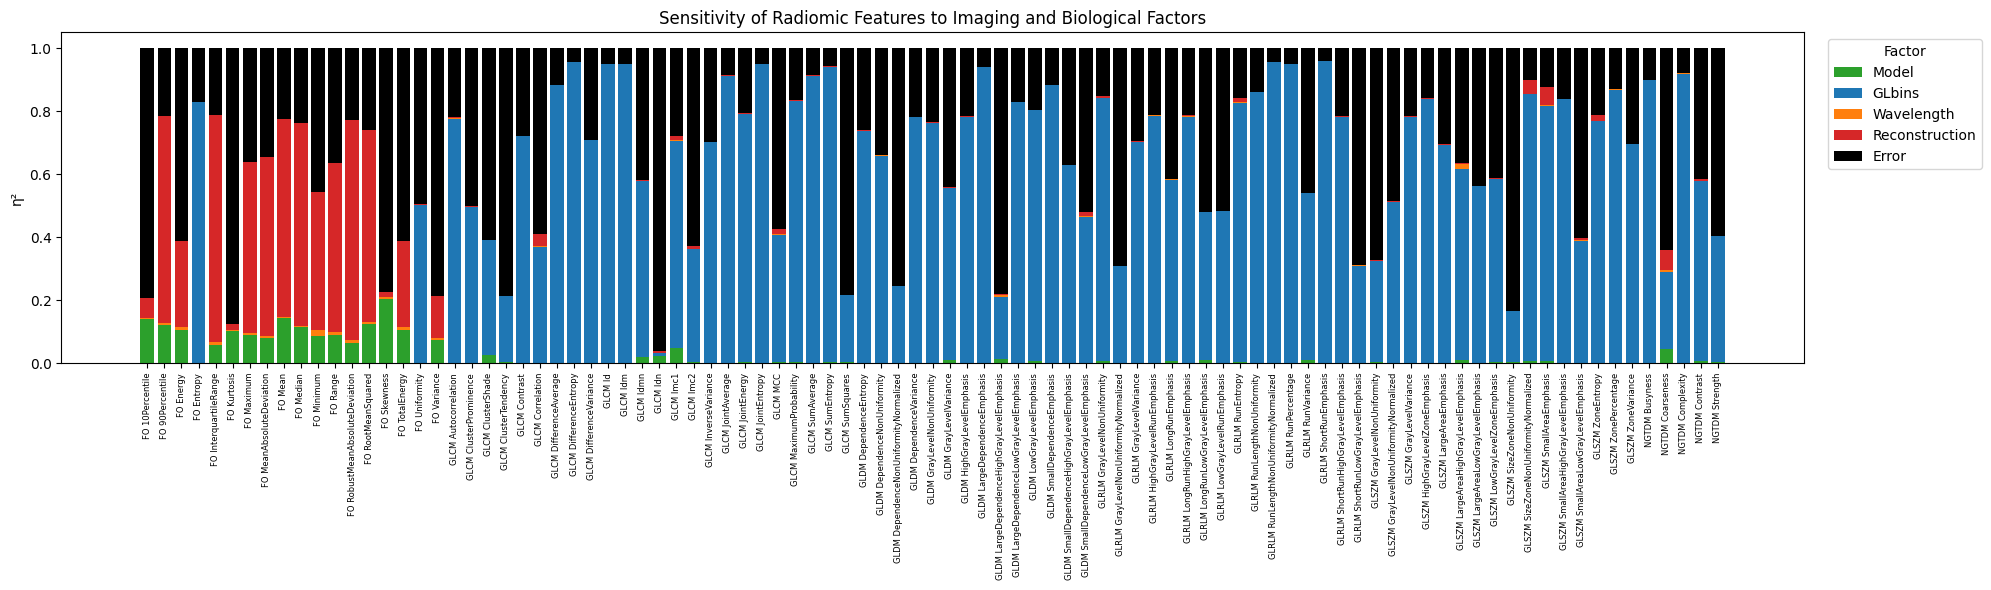

In [356]:
ordering = [
    "RadiomicsFeatures_21cases_8bins.csv",
    "RadiomicsFeatures_21cases_8bins_MB.csv",
    "RadiomicsFeatures_21cases_16bins.csv",
    "RadiomicsFeatures_21cases_16bins_MB.csv",
    "RadiomicsFeatures_21cases_32bins.csv",
    "RadiomicsFeatures_21cases_32bins_MB.csv",
    "RadiomicsFeatures_21cases_64bins.csv",
    "RadiomicsFeatures_21cases_64bins_MB.csv",
    "RadiomicsFeatures_21cases_128bins.csv",
    "RadiomicsFeatures_21cases_128bins_MB.csv",
    "RadiomicsFeatures_21cases_256bins.csv",
    "RadiomicsFeatures_21cases_256bins_MB.csv"
]

# ordering_alt = [
#     "RadiomicsFeatures_21cases_256bins_MB.csv",
#     "RadiomicsFeatures_21cases_256bins.csv",
#     "RadiomicsFeatures_21cases_128bins_MB.csv",
#     "RadiomicsFeatures_21cases_128bins.csv",
#     "RadiomicsFeatures_21cases_64bins_MB.csv",
#     "RadiomicsFeatures_21cases_64bins.csv",
#     "RadiomicsFeatures_21cases_32bins_MB.csv",
#     "RadiomicsFeatures_21cases_32bins.csv",
#     "RadiomicsFeatures_21cases_16bins_MB.csv",
#     "RadiomicsFeatures_21cases_16bins.csv",
#     "RadiomicsFeatures_21cases_8bins_MB.csv",
#     "RadiomicsFeatures_21cases_8bins.csv"
# ]



df_features = pd.read_csv("data/All_features_corrected_final_patient.csv")
df_labels = pd.read_csv("data/All_model.csv", header=None, names=["Model"], skiprows=1)  # no header

# Attach labels directly
df_features["Model"] = df_labels["Model"]


folder = "data/ModelsUncorrected"
files = [f for f in ordering]  # use fixed order above
metadata_blocks = []

for f in files:
    df_meta = pd.read_csv(os.path.join(folder, f), usecols=["PatientName", "Wavelength", "GLbins"])
    df_meta["Reconstruction"] = "MB" if "_MB" in f else "BP"
    metadata_blocks.append(df_meta)

df_metadata = pd.concat(metadata_blocks, ignore_index=True)
assert len(df_metadata) == len(df_features), "Metadata length mismatch!"

df_combined = pd.concat([df_features.reset_index(drop=True), df_metadata.reset_index(drop=True)], axis=1)

# Find all columns including their actual name object (even if repeated)
cols = pd.Series(df_combined.columns)
duplicates = cols[cols.duplicated(keep=False)]
# print("Duplicate columns:\n", duplicates)

df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

# Get all luminal patient IDs
luminal_ids = df_combined[df_combined["Model"] == "luminal"]["PatientName"].unique()

# Pick one randomly (or use a fixed ID for reproducibility)
np.random.seed(42)
drop_id = np.random.choice(luminal_ids, 1)[0]
print(f"Dropping Luminal patient: {drop_id}")

# Drop all rows for that patient
df_combined = df_combined[df_combined["PatientName"] != drop_id].reset_index(drop=True)
print("✅ Final combined shape after dropping patient:", df_combined.shape)

for i in range(12):
    chunk = df_metadata.iloc[i*189:(i+1)*189]
    print(f"Block {i}: GLbins = {chunk['GLbins'].unique()}, Recon = {chunk['Reconstruction'].unique()}")

# Ensure categorical types
for col in ["Model", "GLbins", "Wavelength", "Reconstruction"]:
    df_combined[col] = df_combined[col].astype("category")

# Identify feature columns (exclude metadata + patient)
exclude_cols = ["PatientName", "Model", "GLbins", "Wavelength", "Reconstruction"]
feature_cols = df_combined.drop(columns=exclude_cols).select_dtypes("number").columns.tolist()


import statsmodels.api as sm
from statsmodels.formula.api import ols
from tqdm import tqdm
import pandas as pd

eta2_list = []

for feature in tqdm(feature_cols):
    try:
        formula = f'Q("{feature}") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)'
        model = ols(formula, data=df_combined).fit()
        aov = sm.stats.anova_lm(model, typ=2)
        ss_total = aov["sum_sq"].sum()
        eta2 = (aov["sum_sq"] / ss_total).to_dict()
        eta2["Feature"] = feature
        eta2_list.append(eta2)
    except Exception as e:
        print(f"⚠️ {feature}: {e}")

# Create dataframe
eta2_df = pd.DataFrame(eta2_list).fillna(0).set_index("Feature")
eta2_df = eta2_df.rename(columns={"Residual": "Error"})
eta2_df.columns = eta2_df.columns.str.replace(r"C\((.*?)\)", r"\1", regex=True)

# Optional reorder
eta2_df = eta2_df[["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]]


import matplotlib.pyplot as plt

def plot_eta2_stacked(df_eta2, title):
    factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]
    colors = {
        "Model": "#2ca02c",          # green
        "GLbins": "#1f77b4",         # blue
        "Wavelength": "#ff7f0e",     # orange
        "Reconstruction": "#d62728", # red
        "Error": "#000000"           # black
    }

    fig, ax = plt.subplots(figsize=(20, 6))
    bottom = pd.Series(0, index=df_eta2.index)

    for factor in factors:
        ax.bar(df_eta2.index, df_eta2[factor], bottom=bottom, label=factor, color=colors[factor])
        bottom += df_eta2[factor]

    ax.set_title(title)
    ax.set_ylabel("η²")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(df_eta2)))
    ax.set_xticklabels(df_eta2.index, rotation=90, fontsize=6)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Factor")
    plt.tight_layout()
    plt.show()

plot_eta2_stacked(eta2_df, "Sensitivity of Radiomic Features to Imaging and Biological Factors")


<Axes: xlabel='Wavelength'>

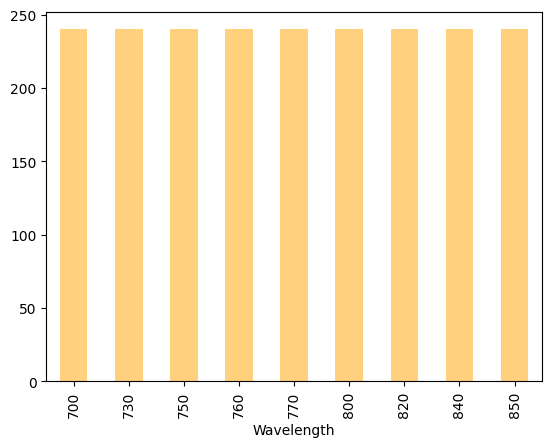

In [349]:
df_combined['Wavelength'].value_counts().plot(kind="bar", alpha=0.5, color="orange", label="GLbins")

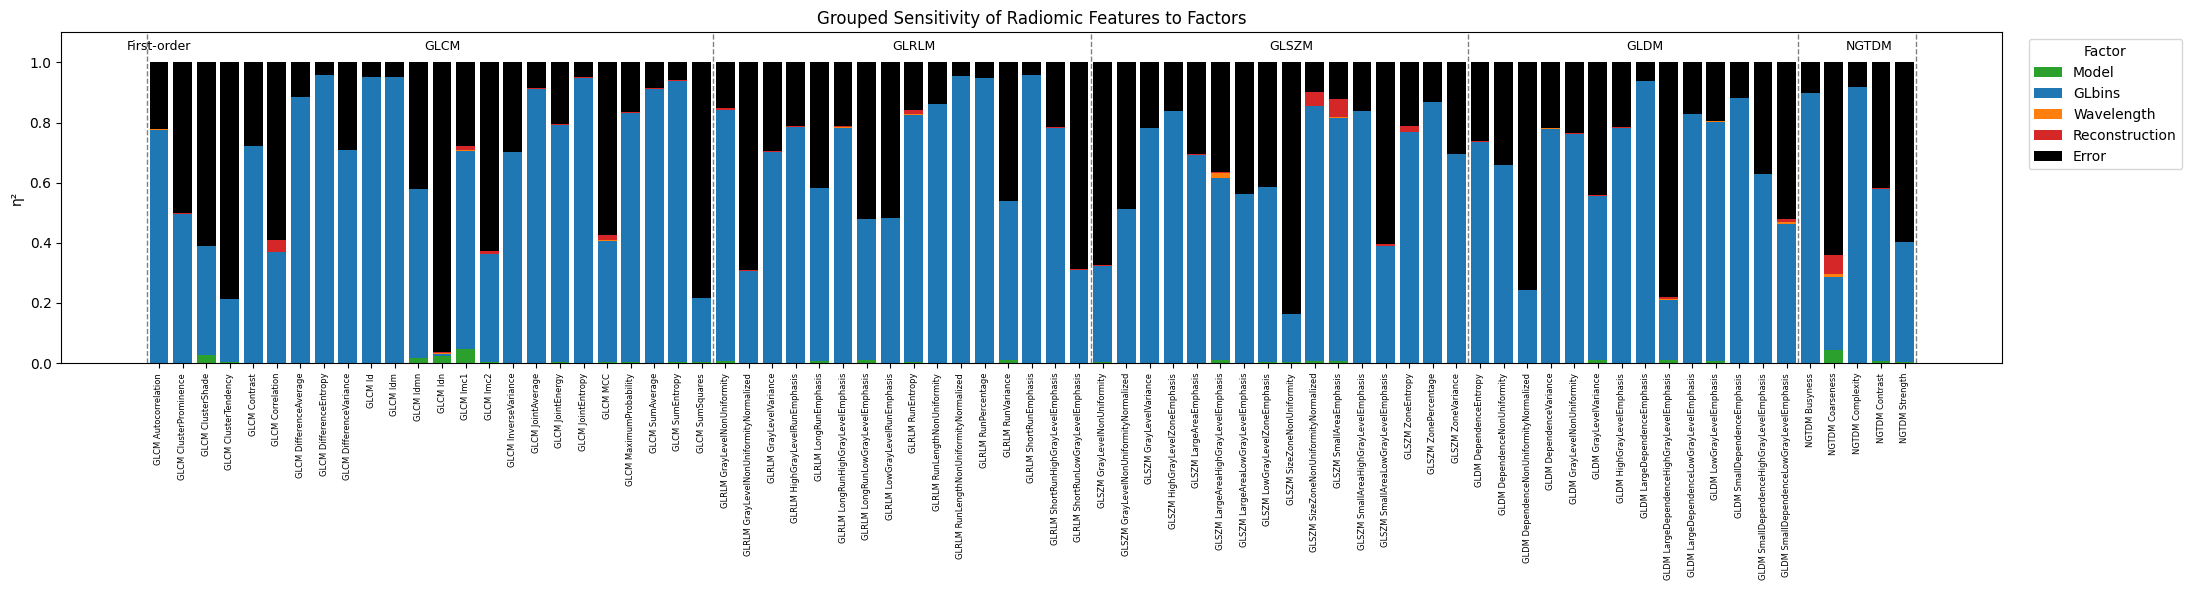

In [297]:
from collections import OrderedDict

# Define feature families and their identifying name fragments
feature_families = OrderedDict({
    "First-order":     ["firstorder", "FOS", "Firstorder"],
    "GLCM":            ["glcm"],
    "GLRLM":           ["glrlm"],
    "GLSZM":           ["glszm"],
    "GLDM":            ["gldm"],
    "NGTDM":           ["ngtdm"]
})

# Assign each feature to a group based on its name
grouped_features = OrderedDict()
for family, fragments in feature_families.items():
    matched = [f for f in eta2_df.index if any(f.lower().startswith(x.lower()) for x in fragments)]
    grouped_features[family] = matched

# Flatten into a new ordered index
ordered_features = [f for group in grouped_features.values() for f in group]

# Filter and reorder η² DataFrame
eta2_grouped = eta2_df.loc[ordered_features]


def plot_eta2_grouped(df_eta2, grouped_features, title):
    factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]
    colors = {
        "Model": "#2ca02c",
        "GLbins": "#1f77b4",
        "Wavelength": "#ff7f0e",
        "Reconstruction": "#d62728",
        "Error": "#000000"
    }

    fig, ax = plt.subplots(figsize=(22, 6))
    bottom = pd.Series(0, index=df_eta2.index)

    for factor in factors:
        ax.bar(df_eta2.index, df_eta2[factor], bottom=bottom, label=factor, color=colors[factor])
        bottom += df_eta2[factor]

    # Family separators and labels
    start = 0
    for family, features in grouped_features.items():
        end = start + len(features)
        ax.axvline(end - 0.5, color="grey", linestyle="--", linewidth=1)
        ax.text((start + end) / 2, 1.03, family, ha="center", va="bottom", fontsize=9)
        start = end

    ax.set_ylabel("η²")
    ax.set_ylim(0, 1.1)
    ax.set_xticks(range(len(df_eta2)))
    ax.set_xticklabels(df_eta2.index, rotation=90, fontsize=6)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Factor")
    plt.tight_layout()
    plt.show()

plot_eta2_grouped(eta2_grouped, grouped_features, "Grouped Sensitivity of Radiomic Features to Factors")


In [325]:
import numpy as np
from statsmodels.formula.api import ols
import statsmodels.api as sm
import pandas as pd

np.random.seed(42)

features_to_check = ["FO Skewness", "FO Kurtosis"]
factors = ["C(Model)", "C(Wavelength)", "C(GLbins)", "C(Reconstruction)", "Residual"]

# Storage structure: {feature: {factor: [η²_1, η²_2, ..., η²_5]}}
eta2_results = {feat: {f: [] for f in factors} for feat in features_to_check}

luminal_ids = df_combined[df_combined["Model"] == "luminal"]["PatientName"].unique()
basal_ids = df_combined[df_combined["Model"] == "basal"]["PatientName"].unique()

def get_eta2_all_factors(feature, df_sample):
    try:
        model = ols(f'Q("{feature}") ~ C(Model) + C(Wavelength) + C(GLbins) + C(Reconstruction)', data=df_sample).fit()
        aov = sm.stats.anova_lm(model, typ=2)
        ss_total = aov["sum_sq"].sum()
        return (aov["sum_sq"] / ss_total).to_dict()
    except Exception as e:
        print(f"⚠️ Failed ANOVA for {feature}: {e}")
        return None

for _ in range(5):
    sampled_ids = np.concatenate([
        np.random.choice(luminal_ids, size=8, replace=False),
        np.random.choice(basal_ids, size=8, replace=False)
    ])
    df_sample = df_combined[df_combined["PatientName"].isin(sampled_ids)]

    for feat in features_to_check:
        eta2 = get_eta2_all_factors(feat, df_sample)
        if eta2 is not None:
            for fac in factors:
                eta2_results[feat][fac].append(eta2.get(fac, np.nan))

# Now calculate mean, std, and CoV for each
summary_tables = {}
for feat in features_to_check:
    stats = {}
    for fac in factors:
        values = np.array(eta2_results[feat][fac])
        mean = np.nanmean(values)
        std = np.nanstd(values)
        cov = std / mean if mean != 0 else np.nan
        stats[fac.replace("C(", "").replace(")", "")] = {
            "mean": round(mean, 3),
            "std": round(std, 3),
            "CoV": round(cov, 2)
        }
    summary_tables[feat] = pd.DataFrame(stats).T

# Display both tables
print("📊 Skewness:")
display(summary_tables["FO Skewness"])

print("\n📊 Kurtosis:")
display(summary_tables["FO Kurtosis"])


📊 Skewness:


,mean,std,CoV
Model,0.215,0.036,0.17
Wavelength,0.006,0.001,0.18
GLbins,0.000,0.000,0.26
Reconstruction,0.015,0.001,0.09
Residual,0.764,0.036,0.05



📊 Kurtosis:


,mean,std,CoV
Model,0.114,0.021,0.18
Wavelength,0.002,0.001,0.35
GLbins,0.000,0.000,0.20
Reconstruction,0.017,0.003,0.19
Residual,0.868,0.021,0.02


In [328]:
# Try one feature with high model sensitivity
feature = "FO Skewness"
formula = f'Q("{feature}") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)'
model = ols(formula, data=df_combined).fit()
aov = sm.stats.anova_lm(model, typ=2)

print(aov)


                         sum_sq      df             F         PR(>F)
C(Model)           4.963673e+02     1.0  5.632516e+02  9.521499e-111
C(GLbins)          8.781262e-27     5.0  1.992903e-27   1.000000e+00
C(Wavelength)      1.318902e+01     8.0  1.870776e+00   6.042046e-02
C(Reconstruction)  3.960876e+01     1.0  4.494594e+01   2.581586e-11
Residual           1.889407e+03  2144.0           NaN            NaN


In [331]:
pivot = df_combined.pivot_table(index="PatientName", values="FO Skewness", aggfunc=np.std)
print(pivot.sort_values("FO Skewness", ascending=False).head())


             FO Skewness
PatientName             
217             0.614906
193             0.502020
199             0.378579
10              0.368202
223             0.353561


/var/folders/th/p1bpkycd1lx_c6j9tvg1m21c0000gn/T/ipykernel_4198/983582565.py:1: FutureWarning: The provided callable <function std at 0x106228280> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  pivot = df_combined.pivot_table(index="PatientName", values="FO Skewness", aggfunc=np.std)


<Axes: xlabel='Model', ylabel='FO Skewness'>

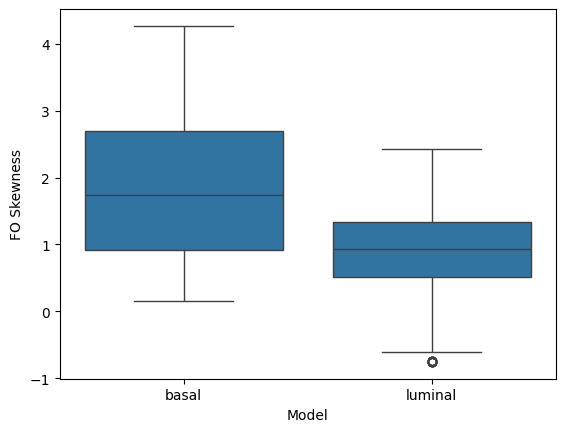

In [334]:
import seaborn as sns
sns.boxplot(data=df_combined, x="Model", y="FO Skewness")


In [335]:
import itertools

def test_metadata_orders(df_features, all_metadata, ordering_files, feature="FO Skewness"):
    best_eta = -1
    best_order = None

    perms = list(itertools.permutations(ordering_files))
    print(f"Testing {len(perms)} permutations...")

    for i, ordering in enumerate(perms):
        meta_blocks = []
        for f in ordering:
            df_meta = pd.read_csv(os.path.join(folder, f), usecols=["Wavelength", "GLbins"])
            df_meta["Reconstruction"] = "MB" if "_MB" in f else "BP"
            meta_blocks.append(df_meta)

        meta = pd.concat(meta_blocks, ignore_index=True)
        combined = pd.concat([df_features.reset_index(drop=True), meta.reset_index(drop=True)], axis=1)

        try:
            model = ols(f'Q("{feature}") ~ C(Model) + C(GLbins) + C(Wavelength) + C(Reconstruction)', data=combined).fit()
            aov = sm.stats.anova_lm(model, typ=2)
            ss_total = aov["sum_sq"].sum()
            eta2 = (aov["sum_sq"] / ss_total).to_dict()

            if eta2["C(Model)"] > best_eta:
                best_eta = eta2["C(Model)"]
                best_order = ordering

        except Exception as e:
            print(f"⚠️ Order {i} failed:", e)

        if i % 100 == 0:
            print(f"{i} / {len(perms)} tested")

    return best_order, best_eta

best_order, max_eta = test_metadata_orders(df_features, df_metadata, ordering[:6])  # Start with just 6 for speed

print("Best order:", best_order)
print("Max η² (Model):", max_eta)


Testing 720 permutations...
0 / 720 tested
100 / 720 tested
200 / 720 tested
300 / 720 tested
400 / 720 tested
500 / 720 tested
600 / 720 tested
700 / 720 tested
Best order: ('RadiomicsFeatures_21cases_32bins_MB.csv', 'RadiomicsFeatures_21cases_8bins_MB.csv', 'RadiomicsFeatures_21cases_32bins.csv', 'RadiomicsFeatures_21cases_16bins_MB.csv', 'RadiomicsFeatures_21cases_8bins.csv', 'RadiomicsFeatures_21cases_16bins.csv')
Max η² (Model): 0.22116133281065292


In [336]:
print(df_features.columns[df_features.columns.str.contains("GLbins|Reconstruction|Wavelength", case=False)])


Index([], dtype='object')


In [ ]:
import pandas as pd
import numpy as np

def manual_anova_sensitivity(y, factors_df):
    """
    Manually compute ANOVA eta² (sensitivity) values for a given feature.

    Parameters:
    - y: 1D array-like (e.g. Series), the feature values
    - factors_df: DataFrame with columns: ['Model', 'GLbins', 'Wavelength', 'Reconstruction']

    Returns:
    - eta2_dict: Dictionary of η² values for each factor and residual ("Error")
    """
    df = factors_df.copy()
    df["y"] = y.values if isinstance(y, pd.Series) else y

    grand_mean = df["y"].mean()
    ss_total = ((df["y"] - grand_mean) ** 2).sum()

    eta2_dict = {}
    ss_used = 0

    for col in ["Model", "GLbins", "Wavelength", "Reconstruction"]:
        ss_factor = 0
        for level in df[col].unique():
            group = df[df[col] == level]["y"]
            group_mean = group.mean()
            ss_factor += len(group) * (group_mean - grand_mean) ** 2
        eta2_dict[col] = ss_factor / ss_total
        ss_used += ss_factor

    eta2_dict["Error"] = max(0.0, 1.0 - ss_used / ss_total)
    return eta2_dict


In [365]:
from tqdm import tqdm

eta2_list = []

for feature in tqdm(feature_cols):
    eta2 = manual_anova_sensitivity(
        df_combined[feature],
        df_combined[["Model", "GLbins", "Wavelength", "Reconstruction"]]
    )
    eta2["Feature"] = feature
    eta2_list.append(eta2)

eta2_manual_df = pd.DataFrame(eta2_list).set_index("Feature")
eta2_manual_df = eta2_manual_df[["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]]


100%|██████████| 93/93 [00:00<00:00, 178.25it/s]


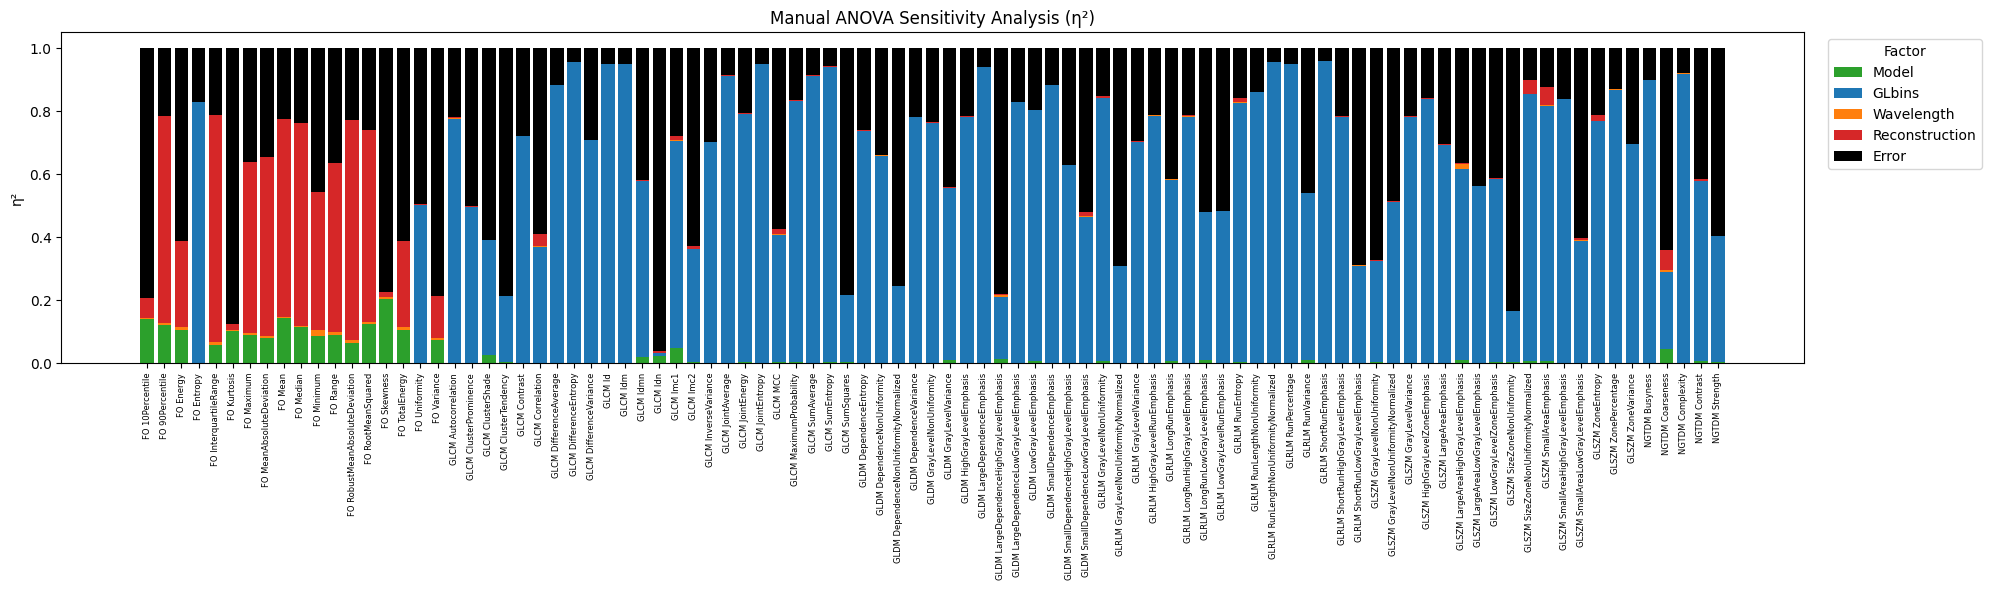

In [366]:
import matplotlib.pyplot as plt

def plot_eta2_stacked(df_eta2, title):
    factors = ["Model", "GLbins", "Wavelength", "Reconstruction", "Error"]
    colors = {
        "Model": "#2ca02c",
        "GLbins": "#1f77b4",
        "Wavelength": "#ff7f0e",
        "Reconstruction": "#d62728",
        "Error": "#000000"
    }

    fig, ax = plt.subplots(figsize=(20, 6))
    bottom = pd.Series(0, index=df_eta2.index)

    for factor in factors:
        ax.bar(df_eta2.index, df_eta2[factor], bottom=bottom, label=factor, color=colors[factor])
        bottom += df_eta2[factor]

    ax.set_title(title)
    ax.set_ylabel("η²")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(df_eta2)))
    ax.set_xticklabels(df_eta2.index, rotation=90, fontsize=6)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Factor")
    plt.tight_layout()
    plt.show()

plot_eta2_stacked(eta2_manual_df, "Manual ANOVA Sensitivity Analysis (η²)")
